# 1 Introduction

Car rental firms face a big risk from road accidents since they can damage cars, raise insurance costs, generate legal problems, and hurt drivers and passengers. Some accidents are not very dangerous, while others can be quite serious. This is why it's important for a car rental firm to know how bad an accident may be that a driver might be in.

The basic goal of this research is to use information about the driver, the car, and the road conditions to figure out how bad an accident will be. The goal is to look at prior accidents to uncover patterns that can help us guess how bad an accident will be. In short, the corporation aims to leverage past data to make smarter judgments about risk.

This issue is significant in practice since an effective prediction model might benefit the organization in several ways. For instance, it might help the organization make better judgments about pricing, arrange for insurance, and find circumstances where extra care may be needed. The corporation can make better decisions if it learns that specific kinds of drivers, cars, or road conditions are associated to more serious incidents. For instance, if driving at night in bad weather is associated to more major accidents, the firm can opt to provide extra safety tips or change the rental terms in similar scenarios.

This project will use the Accident_Index column to integrate the accidents dataset with the cars dataset to solve this business challenge. After the two datasets are combined, exploratory data analysis will be done to learn more about the data, including the target variable and the important characteristics. Then, the data will be cleaned up by filling in missing values, encoding categorical variables, finding outliers, and choosing suitable features for modeling.

After preprocessing, a basic model will be made to use as a simple point of reference. After then, at least two machine learning models that use distinct methods will be built and adjusted. We will test their performance on a test dataset and talk about the most critical factors that impact the predictions.

The goal of the study is not only to construct models that can accurately forecast the future, but also to figure out what causes accidents to be more serious. This is helpful since machine learning is more beneficial in business when it can make predictions and deliver insights. The main goal of this research is to illustrate how machine learning may assist a car rental firm learn more about the likelihood of accidents and make better decisions.

## 1.1 data loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load raw files
accidents = pd.read_csv("17_accidents.csv")
vehicles = pd.read_csv("17_vehicles.csv")

# clean merge key
accidents_clean = accidents.dropna(subset=["Accident_Index"]).copy()
vehicles_clean = vehicles.dropna(subset=["Accident_Index"]).copy()

# merged raw dataset for EDA
df = accidents_clean.merge(vehicles_clean, on="Accident_Index", how="inner")

print("Accidents shape:", accidents.shape)
print("Vehicles shape:", vehicles.shape)
print("Merged dataset shape:", df.shape)

Accidents shape: (5001, 12)
Vehicles shape: (7914, 9)
Merged dataset shape: (7202, 20)


# 2. Exploratory Data Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load raw files
accidents = pd.read_csv("17_accidents.csv")
vehicles = pd.read_csv("17_vehicles.csv")

# remove rows with missing merge key
accidents_clean = accidents.dropna(subset=["Accident_Index"]).copy()
vehicles_clean = vehicles.dropna(subset=["Accident_Index"]).copy()

# merged dataset for EDA
df = accidents_clean.merge(vehicles_clean, on="Accident_Index", how="inner")

print("Accidents shape:", accidents.shape)
print("Vehicles shape:", vehicles.shape)
print("Merged dataset shape:", df.shape)

Accidents shape: (5001, 12)
Vehicles shape: (7914, 9)
Merged dataset shape: (7202, 20)


## 2.1 Dataset Overview

In [14]:
import pandas as pd

# load the datasets
accidents = pd.read_csv("17_accidents.csv")
vehicles = pd.read_csv("17_vehicles.csv")

# basic shape
print("Accidents dataset shape:", accidents.shape)
print("Vehicles dataset shape:", vehicles.shape)

# preview first few rows
display(accidents.head())
display(vehicles.head())

# column names
print("Accidents columns:")
print(accidents.columns.tolist())

print("\nVehicles columns:")
print(vehicles.columns.tolist())

# data types and non-null counts
print("\nAccidents info:")
accidents.info()

print("\nVehicles info:")
vehicles.info()

Accidents dataset shape: (5001, 12)
Vehicles dataset shape: (7914, 9)


,Longitude,Latitude,Accident_Severity,Day_of_Week,1st_Road_Class,Road_Type,Speed_limit,Light_Conditions,Precipitation,High_Winds,Accident_Index,Datetime
0,-3.197998,52.824776,2,Wednesday,A,Single carriageway,30.501163,Darkness - no lighting,Fine,False,3257.0,1/23/2025 7:55
1,1.221796,51.133317,2,Saturday,A,Dual carriageway,30.501767,Daylight,Fine,False,7541.0,11/20/2025 6:11
2,-1.486036,55.534629,3,Wednesday,A,Single carriageway,19.906256,Daylight,Fine,False,4194.0,8/19/2025 12:00
3,-2.460741,52.287720,3,Thursday,A,Dual carriageway,60.346470,Daylight,Fine,False,2830.0,11/25/2025 18:09
4,-1.132193,52.730579,3,Saturday,A,Single carriageway,30.860881,Daylight,Fine,False,2543.0,7/21/2025 11:48


,Vehicle_Type,Towing_and_Articulation,Was_Vehicle_Left_Hand_Drive?,Journey_Purpose_of_Driver,Age_of_Driver,Engine_Capacity_(CC),Age_of_Vehicle,Driver_IMD_Decile,Accident_Index
0,Van / Goods 3.5 tonnes mgw or under,No tow/articulation,No,Commuting to/from work,26,2299.892099,18.000000,4,3257.0
1,Car,No tow/articulation,Data missing or out of range,Not known,57,2254.998801,18.000000,2,7541.0
2,Car,No tow/articulation,No,Journey as part of work,34,1535.686603,12.981385,-1,4194.0
3,Van / Goods 3.5 tonnes mgw or under,No tow/articulation,No,Commuting to/from work,58,1261.871808,3.248778,3,2830.0
4,Car,No tow/articulation,No,Not known,23,-1.000000,-1.000000,9,2543.0


Accidents columns:
['Longitude', 'Latitude', 'Accident_Severity', 'Day_of_Week', '1st_Road_Class', 'Road_Type', 'Speed_limit', 'Light_Conditions', 'Precipitation', 'High_Winds', 'Accident_Index', 'Datetime']

Vehicles columns:
['Vehicle_Type', 'Towing_and_Articulation', 'Was_Vehicle_Left_Hand_Drive?', 'Journey_Purpose_of_Driver', 'Age_of_Driver', 'Engine_Capacity_(CC)', 'Age_of_Vehicle', 'Driver_IMD_Decile', 'Accident_Index']

Accidents info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Longitude          5001 non-null   float64
 1   Latitude           5001 non-null   float64
 2   Accident_Severity  5001 non-null   int64  
 3   Day_of_Week        5001 non-null   object 
 4   1st_Road_Class     5001 non-null   object 
 5   Road_Type          5001 non-null   object 
 6   Speed_limit        5001 non-null   float64
 7   Light_Con

## 2.2 Merging the Datasets

In [17]:
# check missing Accident_Index values before merging
print("Missing Accident_Index in accidents:", accidents["Accident_Index"].isna().sum())
print("Missing Accident_Index in vehicles:", vehicles["Accident_Index"].isna().sum())


accidents_clean = accidents.dropna(subset=["Accident_Index"]).copy()
vehicles_clean = vehicles.dropna(subset=["Accident_Index"]).copy()

# merge the two datasets
df = accidents_clean.merge(vehicles_clean, on="Accident_Index", how="inner")

# check the merged dataset
print("Merged dataset shape:", df.shape)
print("Unique accidents in merged data:", df["Accident_Index"].nunique())

display(df.head())

Missing Accident_Index in accidents: 1
Missing Accident_Index in vehicles: 712
Merged dataset shape: (7202, 20)
Unique accidents in merged data: 5000


,Longitude,Latitude,Accident_Severity,Day_of_Week,1st_Road_Class,Road_Type,Speed_limit,Light_Conditions,Precipitation,High_Winds,Accident_Index,Datetime,Vehicle_Type,Towing_and_Articulation,Was_Vehicle_Left_Hand_Drive?,Journey_Purpose_of_Driver,Age_of_Driver,Engine_Capacity_(CC),Age_of_Vehicle,Driver_IMD_Decile
0,-3.197998,52.824776,2,Wednesday,A,Single carriageway,30.501163,Darkness - no lighting,Fine,False,3257.0,1/23/2025 7:55,Van / Goods 3.5 tonnes mgw or under,No tow/articulation,No,Commuting to/from work,26,2299.892099,18.000000,4
1,1.221796,51.133317,2,Saturday,A,Dual carriageway,30.501767,Daylight,Fine,False,7541.0,11/20/2025 6:11,Car,No tow/articulation,Data missing or out of range,Not known,57,2254.998801,18.000000,2
2,-1.486036,55.534629,3,Wednesday,A,Single carriageway,19.906256,Daylight,Fine,False,4194.0,8/19/2025 12:00,Car,No tow/articulation,No,Journey as part of work,34,1535.686603,12.981385,-1
3,-1.486036,55.534629,3,Wednesday,A,Single carriageway,19.906256,Daylight,Fine,False,4194.0,8/19/2025 12:00,Car,No tow/articulation,No,Not known,29,-1.000000,8.524924,8
4,-2.460741,52.287720,3,Thursday,A,Dual carriageway,60.346470,Daylight,Fine,False,2830.0,11/25/2025 18:09,Van / Goods 3.5 tonnes mgw or under,No tow/articulation,No,Commuting to/from work,58,1261.871808,3.248778,3


These findings show that Accident_Index was used to integrate the datasets. Missing Accident_Index rows were eliminated since they could not be connected across files. Since Accident_Index is an identifier, it wasn't suitable to fill in the missing data. Because accidents might include many vehicles, the combined dataset has more rows than the accidents dataset. So the combined dataset includes 7,202 rows but only 5,000 unique accidents. Thus, the final dataset is organized by vehicle while retaining accident severity and circumstances. The project benefits because the prediction challenge requires driver, vehicle, and driving condition data. We now have one dataset for exploratory analysis and model building after combining the files.This phase affects the project greatly. A correct merging guarantees that further preprocessing and modeling use the right accident and vehicle data. Without this, the model would learn from improper data associations and produce unreliable results.

## 2.3 Target Variable Distribution

We must understand the target variable before creating a model. Project goal variable is Accident_Severity. This phase shows us the severity class distribution and potential imbalance. This matters because an uneven goal affects model training and evaluation.

Accident severity counts:
Accident_Severity
1     108
2    1283
3    5811
Name: count, dtype: int64

Accident severity percentages:
Accident_Severity
1     1.50
2    17.81
3    80.69
Name: proportion, dtype: float64


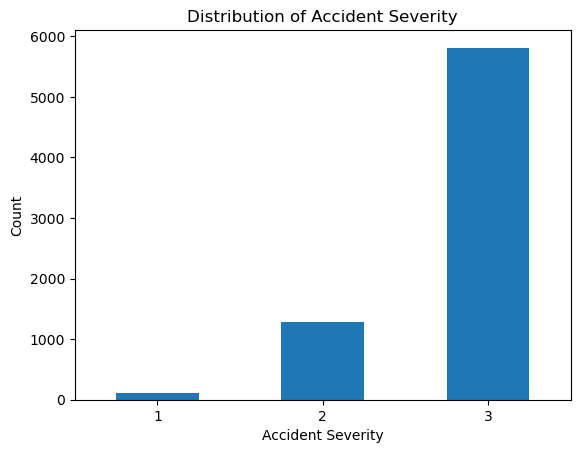

In [22]:
# check the distribution of the target variable
severity_counts = df["Accident_Severity"].value_counts().sort_index()
severity_percent = df["Accident_Severity"].value_counts(normalize=True).sort_index() * 100

print("Accident severity counts:")
print(severity_counts)

print("\nAccident severity percentages:")
print(severity_percent.round(2))

# plot the distribution
import matplotlib.pyplot as plt

severity_counts.plot(kind="bar")
plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Accident_Severity is unbalanced. The majority of observations are Severity 3, with 80.69%, while Severity 1 accounts for 1.50%. The dataset has far more samples of one type than others.Because forecasting the majority class most of the time can give a model great accuracy. A model like this would fail on rarer but more critical severity levels. In following parts, model performance will not be measured by accuracy alone. The confusion matrix, macro recall, macro F1, weighted F1, and other metrics will be utilized to evaluate all courses more fairly.

## 2.4 Missing Values and Invalid Entries

### 2.4.1 Standard Missing Values

Checking standard missing values is the initial data quality check. Blank cells or NaN values. Before checking for placeholder values, this phase determines if any variables are incomplete.

In [28]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Columns with standard missing values:")
print(missing_counts if len(missing_counts) > 0 else "No standard missing values found.")

Columns with standard missing values:
No standard missing values found.


### 2.4.2 Placeholder Values Such as -1

In [31]:
cols_with_minus1 = [
    "Engine_Capacity_(CC)",
    "Age_of_Vehicle",
    "Driver_IMD_Decile",
    "Age_of_Driver"
]

minus1_counts = {}
for col in cols_with_minus1:
    minus1_counts[col] = (df[col] == -1).sum()

minus1_counts = pd.Series(minus1_counts).sort_values(ascending=False)

print("Number of -1 values in selected columns:")
print(minus1_counts)

Number of -1 values in selected columns:
Age_of_Vehicle          1886
Driver_IMD_Decile       1817
Engine_Capacity_(CC)    1633
Age_of_Driver            981
dtype: int64


In practice, these values are meaningless. A driver cannot be -1 years old, and an engine cannot be -1. These values are placeholders for missing data. Leaving them unaltered may lead the model to treat them as extremely tiny actual values rather than missing values. It would produce spurious patterns and lower model dependability. Therefore, preprocessing will turn these -1 values to suitable missing values and impute them.

### 2.4.3 Duplicate Records

In [35]:
full_duplicates = df.duplicated().sum()
print("Number of exact duplicate rows:", full_duplicates)

accident_index_duplicates = df["Accident_Index"].duplicated().sum()
print("Number of repeated Accident_Index values:", accident_index_duplicates)

Number of exact duplicate rows: 0
Number of repeated Accident_Index values: 2202


In simple words, repeated accident IDs here can be normal, while exact duplicate rows may be problematic.

### 2.4.4 Out-of-Range Values

In [39]:
out_of_range = {
    "Age_of_Driver_below_16_or_above_100": df[(df["Age_of_Driver"] != -1) & ((df["Age_of_Driver"] < 16) | (df["Age_of_Driver"] > 100))].shape[0],
    "Age_of_Vehicle_below_0_or_above_80": df[(df["Age_of_Vehicle"] != -1) & ((df["Age_of_Vehicle"] < 0) | (df["Age_of_Vehicle"] > 80))].shape[0],
    "Engine_Capacity_below_0": df[(df["Engine_Capacity_(CC)"] != -1) & (df["Engine_Capacity_(CC)"] < 0)].shape[0],
    "Driver_IMD_Decile_outside_1_to_10": df[(df["Driver_IMD_Decile"] != -1) & ((df["Driver_IMD_Decile"] < 1) | (df["Driver_IMD_Decile"] > 10))].shape[0],
}

out_of_range = pd.Series(out_of_range)

print("Out-of-range value counts:")
print(out_of_range)

Out-of-range value counts:
Age_of_Driver_below_16_or_above_100    67
Age_of_Vehicle_below_0_or_above_80     58
Engine_Capacity_below_0                 0
Driver_IMD_Decile_outside_1_to_10       0
dtype: int64


Checking data quality boosts confidence. Unrealistic values may exist even when present. A motorist above 100 or under the legal driving age may indicate a data input error. Furthermore, an IMD decile outside the typical 1 to 10 range is invalid. Unrealistic values may impair EDA and modeling. They can alter summary statistics, outlier analysis, and model quality if not handled appropriately. These troublesome values must be carefully checked and managed during preprocessing.

## 2.5 Numerical Variable Analysis

,count,mean,std,min,25%,50%,75%,max
Speed_limit,7202.0,37.707517,14.282756,13.112323,29.936016,30.563296,41.327646,75.886033
Age_of_Driver,6221.0,40.943257,16.708552,4.000000,27.000000,39.000000,52.000000,99.000000
Age_of_Vehicle,5316.0,15.059174,14.032570,0.016147,6.000000,12.745031,20.885703,129.462625
Engine_Capacity_(CC),5569.0,1912.797699,1706.592377,14.921374,1248.875426,1598.000000,2016.677248,17668.194240
Driver_IMD_Decile,5385.0,5.139461,2.821466,1.000000,3.000000,5.000000,7.000000,10.000000
Longitude,7202.0,-1.271303,1.402453,-7.190532,-2.135328,-1.149694,-0.244698,1.758123
Latitude,7202.0,52.474928,1.344893,50.090966,51.471470,52.256671,53.203819,60.056863


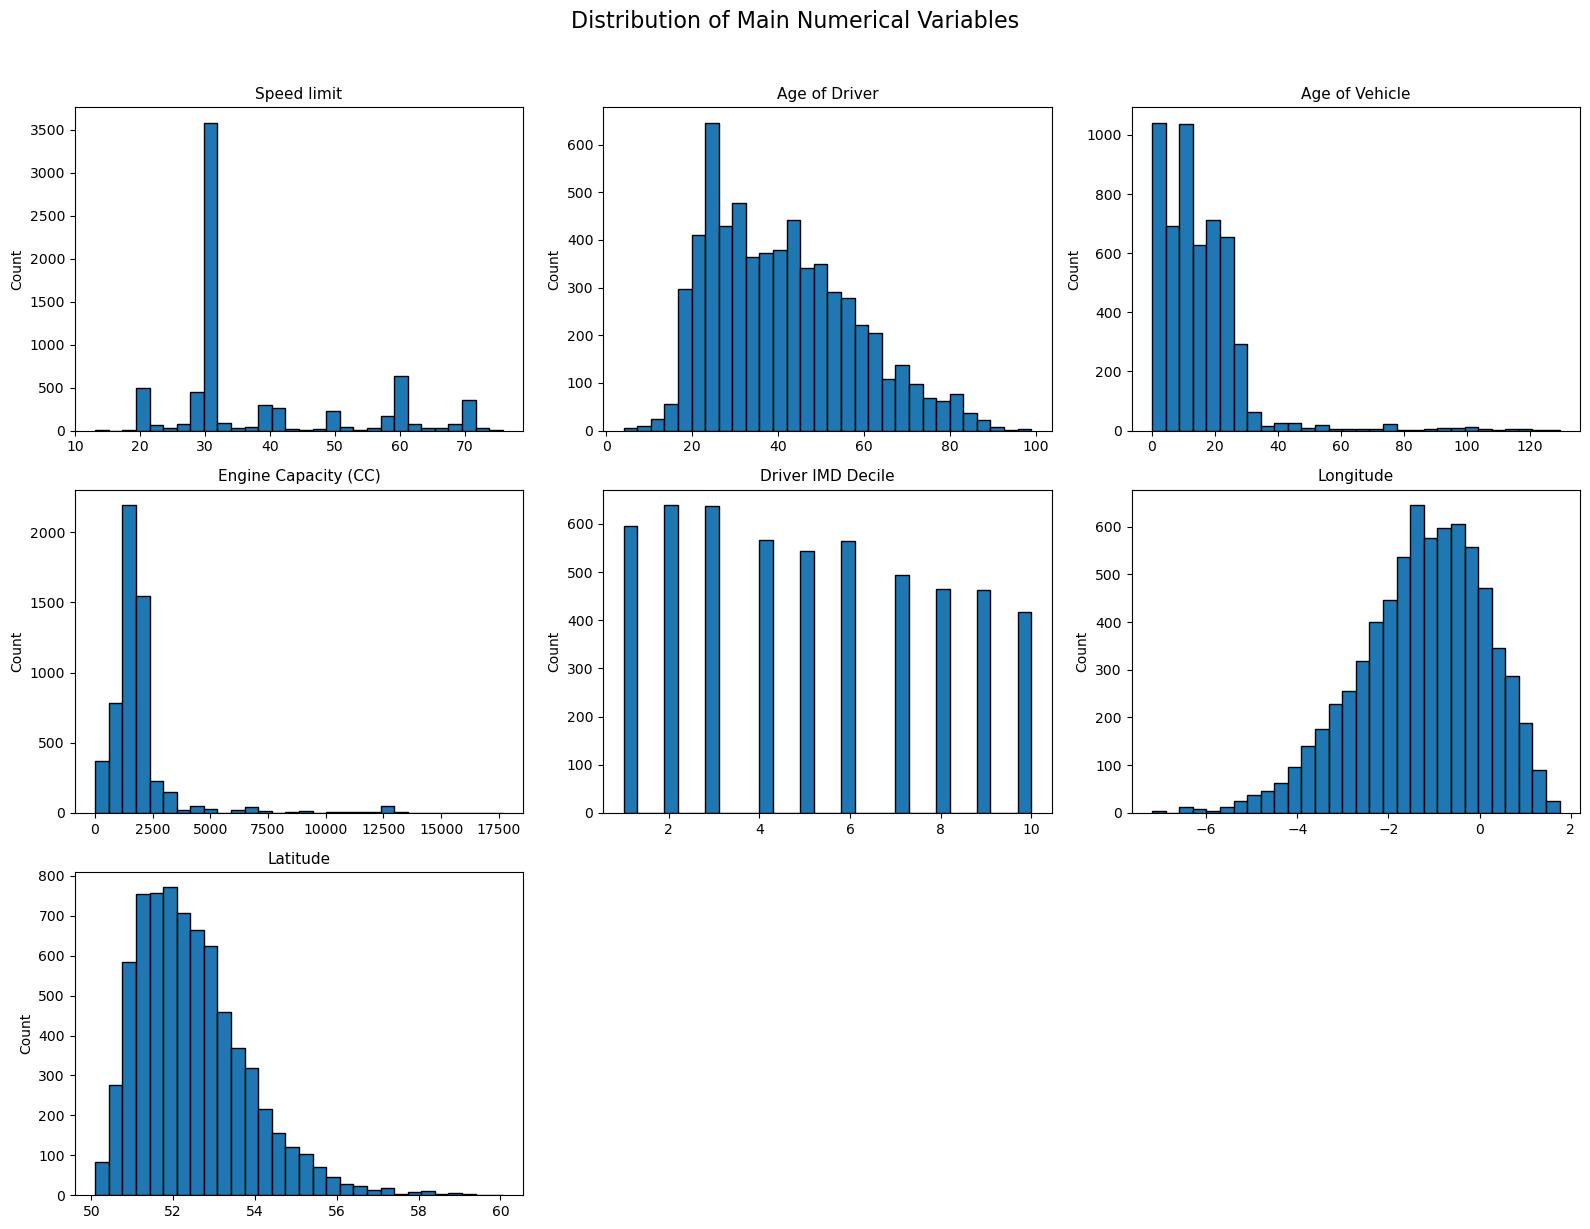

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# make a copy for plotting so invalid -1 values do not distort the graphs
df_num = df.copy()

cols_with_minus1 = [
    "Engine_Capacity_(CC)",
    "Age_of_Vehicle",
    "Driver_IMD_Decile",
    "Age_of_Driver"
]

for col in cols_with_minus1:
    df_num[col] = df_num[col].replace(-1, np.nan)

# select main numerical columns
num_cols = [
    "Speed_limit",
    "Age_of_Driver",
    "Age_of_Vehicle",
    "Engine_Capacity_(CC)",
    "Driver_IMD_Decile",
    "Longitude",
    "Latitude"
]

# summary statistics
display(df_num[num_cols].describe().T)

# histograms
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_num[col].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(col.replace("_", " "), fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# remove unused subplot spaces
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Main Numerical Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Some variables, such Age_of_Vehicle and Engine_Capacity_(CC), could have a lengthy right tail. This suggests that most of the data points are close to the lower values, while just a few are far to the right. Most cars and trucks have engines that are modest or medium-sized, while others have engines that are much bigger. The same idea can apply to vehicle age. If a variable is very skewed, it can change how some machine learning approaches work. For instance, a few really big numbers could drive the distribution in one way. This doesn't imply the values are inaccurate right away, but it does signal that the variable may need further attention later.

Histograms also help us find outliers. Values that are substantially more severe than most of the data are called outliers. These might be real unusual incidents or problems with the quality of the data. We are mostly recognizing them by sight at this point. In the preprocessing stage, a more rigorous check for outliers will be done.

It was needed to replace -1 with NaN just for charting because such placeholder values aren't true measurements. They would make the distributions appear more strange than they really are if they were left in the graphs.

In general, this part offers an early idea of how the numbers work. This can help you make better judgments later about how to handle missing data, outliers, and scaling, which can make the machine learning models more stable and accurate.

## 2.6 Categorical Variable Analysis

In [48]:
cat_cols = [
    "Road_Type",
    "Light_Conditions",
    "Precipitation",
    "High_Winds",
    "Journey_Purpose_of_Driver",
    "Was_Vehicle_Left_Hand_Drive?"
]


Value counts for Road_Type:
Road_Type
Single carriageway    5085
Dual carriageway      1173
Roundabout             450
One way street         228
Unknown                166
Slip road              100
Name: count, dtype: int64

Value counts for Light_Conditions:
Light_Conditions
Daylight                       5238
Darkness - lights lit          1380
Darkness - no lighting          380
Darkness - lighting unknown     167
Darkness - lights unlit          37
Name: count, dtype: int64

Value counts for Precipitation:
Precipitation
Fine                    5825
Raining                  756
Unknown                  207
Other                    172
Raining + high winds      81
Snowing                   53
Fine + high winds         49
Snowing + high winds      30
Fog or mist               29
Name: count, dtype: int64

Value counts for High_Winds:
High_Winds
False    7039
True      163
Name: count, dtype: int64

Value counts for Journey_Purpose_of_Driver:
Journey_Purpose_of_Driver
Not known     

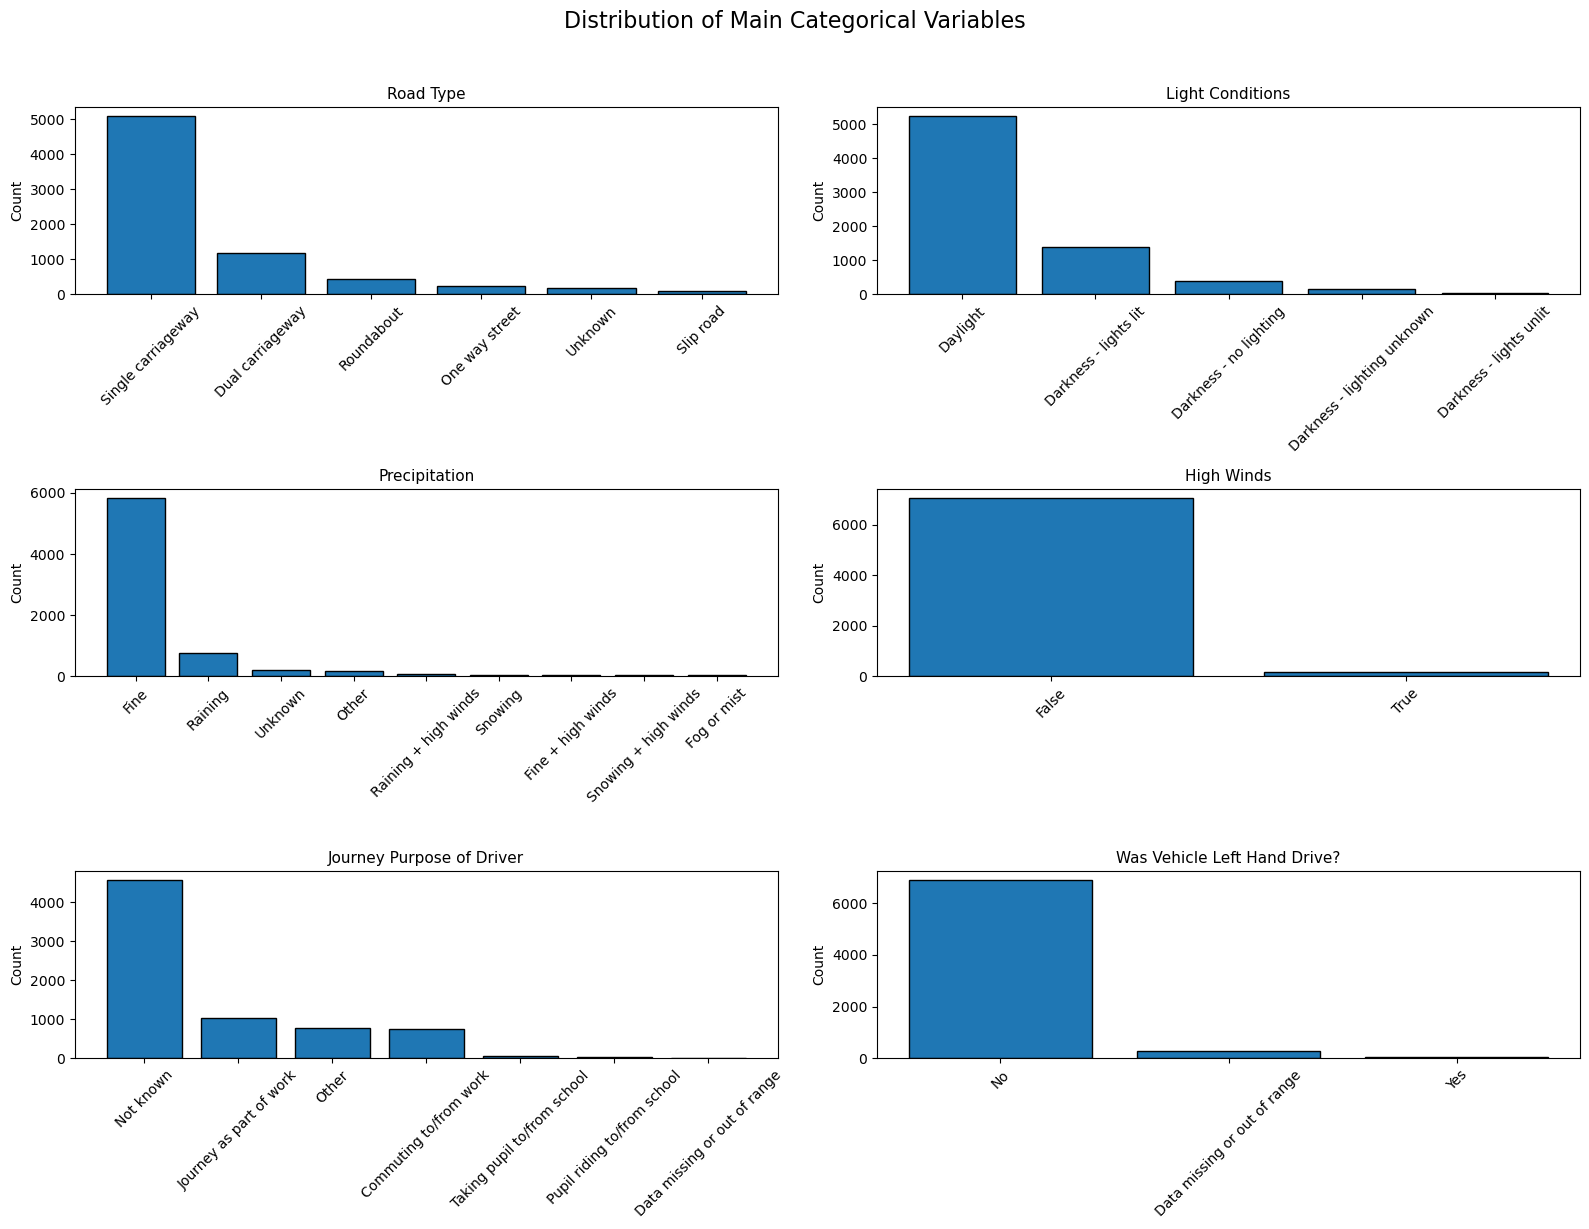

In [49]:
import matplotlib.pyplot as plt

cat_cols = [
    "Road_Type",
    "Light_Conditions",
    "Precipitation",
    "High_Winds",
    "Journey_Purpose_of_Driver",
    "Was_Vehicle_Left_Hand_Drive?"
]

# frequency tables
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))

# bar charts
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts(dropna=False).sort_values(ascending=False)
    axes[i].bar(value_counts.index.astype(str), value_counts.values, edgecolor="black")
    axes[i].set_title(col.replace("_", " "), fontsize=11)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

fig.suptitle("Distribution of Main Categorical Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

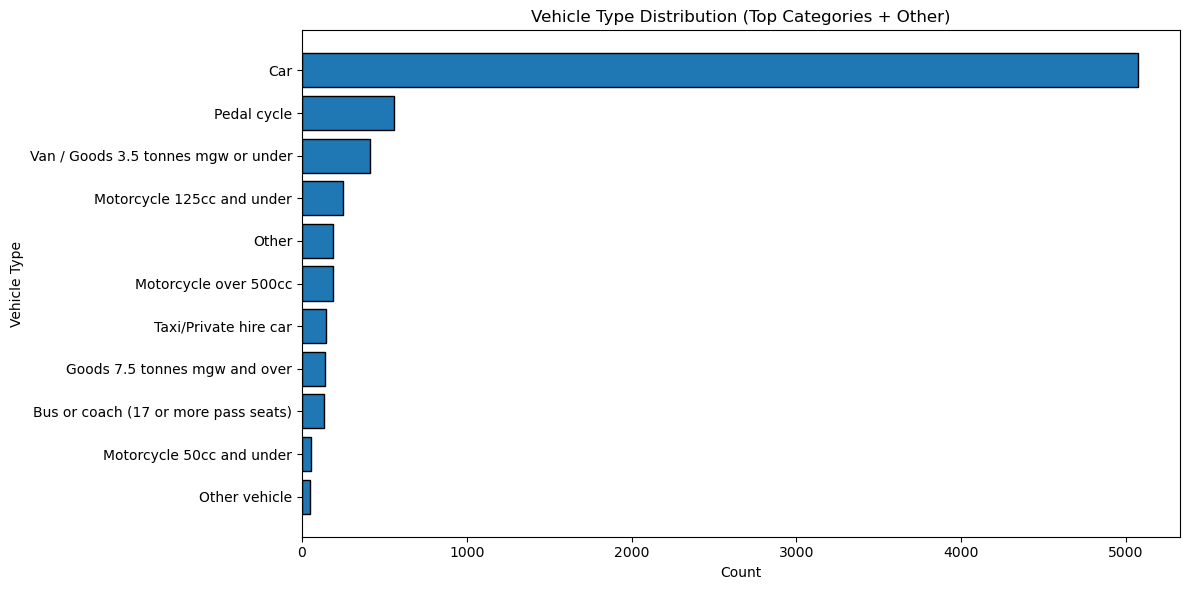

In [50]:
vehicle_counts = df["Vehicle_Type"].value_counts()

top_n = 10
top_categories = vehicle_counts.nlargest(top_n).index

vehicle_grouped = df["Vehicle_Type"].where(df["Vehicle_Type"].isin(top_categories), "Other")
grouped_counts = vehicle_grouped.value_counts()

plt.figure(figsize=(12, 6))
plt.barh(grouped_counts.index.astype(str), grouped_counts.values, edgecolor="black")
plt.title("Vehicle Type Distribution (Top Categories + Other)")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This section is useful because categorical variables often carry important real-world information. For example, road type, lighting conditions, weather, vehicle type, and journey purpose may all influence accident severity.The frequency tables and bar charts help us understand the structure of these variables. In many cases, a few categories appear very often, while others appear only rarely. This matters because very small categories may have less predictive value on their own and can sometimes make modelling more difficult after encoding. A simple example is a survey question where most people choose one or two common answers, while only a few choose rare options. The common answers are easier for the model to learn from because there are many examples, while the rare ones may be harder to learn reliably. This section also helps us prepare for preprocessing. Since machine learning models usually work with numbers rather than text labels, these categorical variables will later need to be encoded. By looking at them now, we can better decide how to handle them, especially if some variables have many categories or very unbalanced frequency distributions.
Overall, this step improves our understanding of the non-numerical part of the dataset and helps connect the real-world meaning of the data to a later modeling stage.

## 2.7 Relationship Between Predictors and Accident Severity

So far, each variable has been looked at on its own. The goal of this part is to see how several relevant predictors are related to the objective variable, Accident_Severity. This lets us figure out if specific road conditions, driver traits, or vehicle attributes are related to more serious accidents.


Severity distribution by Speed_limit:
Accident_Severity    1      2      3
Speed_limit                         
13.112323          0.0  100.0    0.0
14.521219          0.0  100.0    0.0
16.580961          0.0    0.0  100.0
17.416964          0.0  100.0    0.0
17.481826          0.0  100.0    0.0
...                ...    ...    ...
73.337883          0.0    0.0  100.0
73.340888          0.0    0.0  100.0
75.299194          0.0    0.0  100.0
75.885359          0.0    0.0  100.0
75.886033          0.0    0.0  100.0

[2769 rows x 3 columns]

Severity distribution by Light_Conditions:
Accident_Severity               1      2      3
Light_Conditions                               
Darkness - lighting unknown  0.00  16.17  83.83
Darkness - lights lit        1.09  16.81  82.10
Darkness - lights unlit      0.00  10.81  89.19
Darkness - no lighting       1.32  17.37  81.32
Daylight                     1.68  18.21  80.11

Severity distribution by Precipitation:
Accident_Severity        1      2 

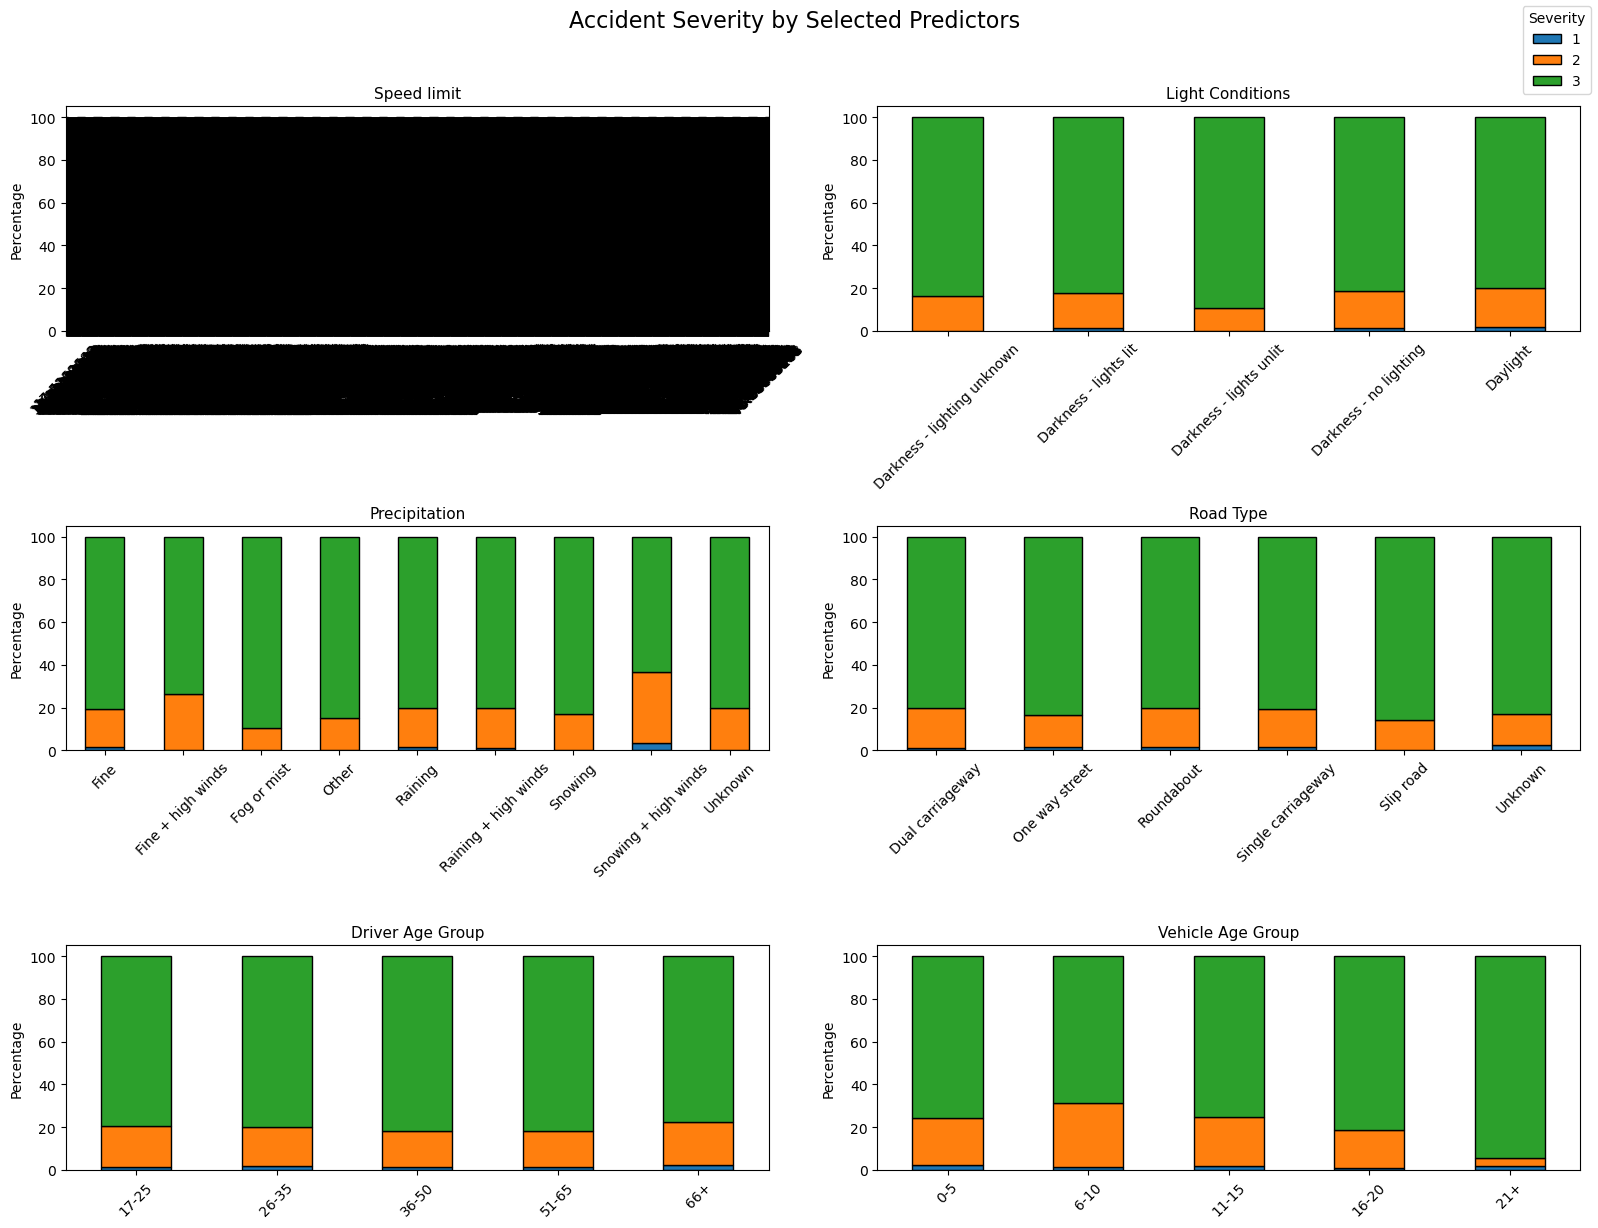

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# make a copy for grouped analysis
df_rel = df.copy()

# replace placeholder -1 values with NaN for grouping
for col in ["Age_of_Driver", "Age_of_Vehicle"]:
    df_rel[col] = df_rel[col].replace(-1, np.nan)

# create grouped variables
df_rel["Driver_Age_Group"] = pd.cut(
    df_rel["Age_of_Driver"],
    bins=[16, 25, 35, 50, 65, 100],
    labels=["17-25", "26-35", "36-50", "51-65", "66+"],
    include_lowest=True
)

df_rel["Vehicle_Age_Group"] = pd.cut(
    df_rel["Age_of_Vehicle"],
    bins=[0, 5, 10, 15, 20, 100],
    labels=["0-5", "6-10", "11-15", "16-20", "21+"],
    include_lowest=True
)

# selected predictors
features_to_check = [
    "Speed_limit",
    "Light_Conditions",
    "Precipitation",
    "Road_Type",
    "Driver_Age_Group",
    "Vehicle_Age_Group"
]

# percentage tables
for feature in features_to_check:
    print(f"\nSeverity distribution by {feature}:")
    table = pd.crosstab(df_rel[feature], df_rel["Accident_Severity"], normalize="index") * 100
    print(table.round(2))

# stacked bar charts
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_check):
    table = pd.crosstab(df_rel[feature], df_rel["Accident_Severity"], normalize="index") * 100
    table = table.round(2)
    table.plot(kind="bar", stacked=True, ax=axes[i], edgecolor="black", legend=False)
    axes[i].set_title(feature.replace("_", " "), fontsize=11)
    axes[i].set_ylabel("Percentage")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Severity", loc="upper right")
fig.suptitle("Accident Severity by Selected Predictors", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The initial output for Speed_limit showed many unusual decimal values instead of the expected road speed categories such as 20, 30, 40, 50, 60, and 70. This suggests that the variable may have been transformed or scaled earlier, which makes it unsuitable for direct interpretation in the EDA section. Because EDA should reflect the data in its original form, the Speed_limit variable will need to be checked and analysed again using the raw unscaled values. This is important because speed limit is likely to be a meaningful predictor of accident severity, but its relationship with the target can only be interpreted properly when the original categories are preserved.

In [58]:
df_rel = df.copy()

# use raw speed limit categories
print(df_rel["Speed_limit"].value_counts().sort_index())

speed_table = pd.crosstab(df_rel["Speed_limit"], df_rel["Accident_Severity"], normalize="index") * 100
print(speed_table.round(2))

Speed_limit
13.112323    10
14.521219     1
16.580961     1
17.416964     1
17.481826     2
             ..
73.337883     1
73.340888     1
75.299194     3
75.885359     4
75.886033     1
Name: count, Length: 2769, dtype: int64
Accident_Severity    1      2      3
Speed_limit                         
13.112323          0.0  100.0    0.0
14.521219          0.0  100.0    0.0
16.580961          0.0    0.0  100.0
17.416964          0.0  100.0    0.0
17.481826          0.0  100.0    0.0
...                ...    ...    ...
73.337883          0.0    0.0  100.0
73.340888          0.0    0.0  100.0
75.299194          0.0    0.0  100.0
75.885359          0.0    0.0  100.0
75.886033          0.0    0.0  100.0

[2769 rows x 3 columns]


In [59]:
df_rel = df.copy()

# use raw speed limit categories
print(df_rel["Speed_limit"].value_counts().sort_index())

speed_table = pd.crosstab(df_rel["Speed_limit"], df_rel["Accident_Severity"], normalize="index") * 100
print(speed_table.round(2))

Speed_limit
13.112323    10
14.521219     1
16.580961     1
17.416964     1
17.481826     2
             ..
73.337883     1
73.340888     1
75.299194     3
75.885359     4
75.886033     1
Name: count, Length: 2769, dtype: int64
Accident_Severity    1      2      3
Speed_limit                         
13.112323          0.0  100.0    0.0
14.521219          0.0  100.0    0.0
16.580961          0.0    0.0  100.0
17.416964          0.0  100.0    0.0
17.481826          0.0  100.0    0.0
...                ...    ...    ...
73.337883          0.0    0.0  100.0
73.340888          0.0    0.0  100.0
75.299194          0.0    0.0  100.0
75.885359          0.0    0.0  100.0
75.886033          0.0    0.0  100.0

[2769 rows x 3 columns]


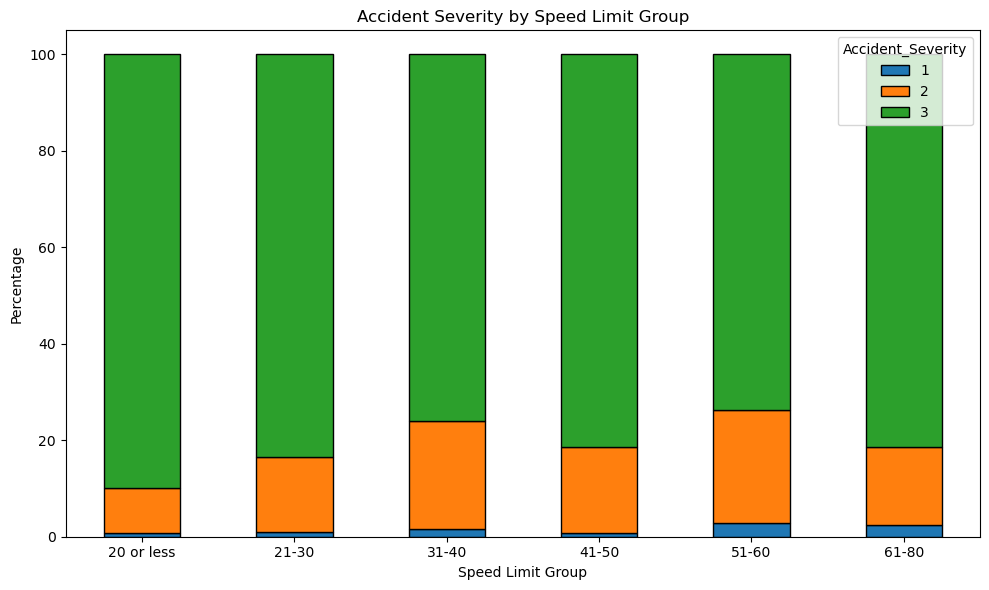

In [65]:
df_rel = df.copy()

df_rel["Speed_limit_Group"] = pd.cut(
    df_rel["Speed_limit"],
    bins=[0, 20, 30, 40, 50, 60, 80],
    labels=["20 or less", "21-30", "31-40", "41-50", "51-60", "61-80"],
    include_lowest=True
)

speed_table = pd.crosstab(
    df_rel["Speed_limit_Group"],
    df_rel["Accident_Severity"],
    normalize="index"
) * 100

speed_table.plot(kind="bar", stacked=True, figsize=(10, 6), edgecolor="black")
plt.title("Accident Severity by Speed Limit Group")
plt.ylabel("Percentage")
plt.xlabel("Speed Limit Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

It was hard to understand the first Speed_limit output since it made too many distinct values in the chart. To fix this, speed restrictions were put into bigger groups. The new figure is much easier to read and indicates that Severity 3 is still the most common type of accident across all groups. However, certain higher speed-limit bands have a higher percentage of more serious incidents. This means that speed limits may be useful for predicting how bad an accident will be, thus they should be kept for modeling.

## 2.8 Time-Related Patterns

Missing Datetime after conversion: 0

Severity distribution by Hour:
Accident_Severity     1      2      3
Hour                                 
0                  0.00   4.17  95.83
1                  2.17  13.04  84.78
2                  0.00  27.50  72.50
3                  0.00  17.44  82.56
4                  2.80  16.82  80.37
5                  0.00  21.08  78.92
6                  0.95  17.62  81.43
7                  3.80  16.73  79.47
8                  1.31  20.98  77.70
9                  1.31  15.22  83.46
10                 2.82  18.08  79.10
11                 1.06  15.83  83.11
12                 0.92  17.66  81.42
13                 0.86  21.63  77.52
14                 2.16  14.72  83.12
15                 1.20  17.56  81.24
16                 1.09  14.52  84.39
17                 0.57  20.38  79.05
18                 0.43  15.65  83.91
19                 1.86  18.10  80.05
20                 2.86  20.48  76.67
21                 2.79  18.47  78.75
22                 

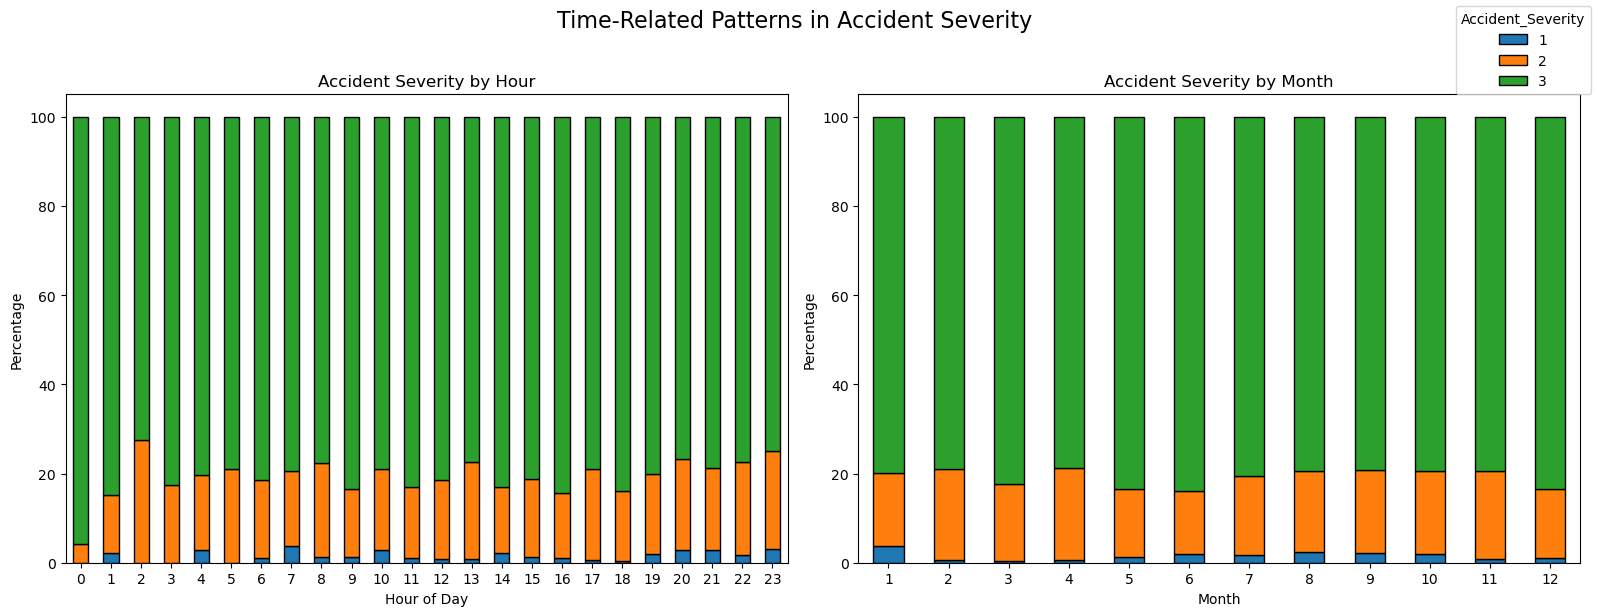

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# make a copy for time analysis
df_time = df.copy()

# convert Datetime to datetime format
df_time["Datetime"] = pd.to_datetime(df_time["Datetime"], errors="coerce")

# create time features
df_time["Hour"] = df_time["Datetime"].dt.hour
df_time["Month"] = df_time["Datetime"].dt.month
df_time["Weekday"] = df_time["Datetime"].dt.day_name()

# check missing values created by parsing
print("Missing Datetime after conversion:", df_time["Datetime"].isna().sum())

# severity distribution by hour
hour_table = pd.crosstab(df_time["Hour"], df_time["Accident_Severity"], normalize="index") * 100
print("\nSeverity distribution by Hour:")
print(hour_table.round(2))

# severity distribution by month
month_table = pd.crosstab(df_time["Month"], df_time["Accident_Severity"], normalize="index") * 100
print("\nSeverity distribution by Month:")
print(month_table.round(2))

# plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hour_table.plot(kind="bar", stacked=True, ax=axes[0], edgecolor="black", legend=False)
axes[0].set_title("Accident Severity by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Percentage")
axes[0].tick_params(axis="x", rotation=0)

month_table.plot(kind="bar", stacked=True, ax=axes[1], edgecolor="black", legend=False)
axes[1].set_title("Accident Severity by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Percentage")
axes[1].tick_params(axis="x", rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Accident_Severity", loc="upper right")
fig.suptitle("Time-Related Patterns in Accident Severity", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

The analysis by time reveals that Severity 3 is the most prevalent outcome at all hours and in all months. The general pattern is still the same, but there are certain differences that may be noted during the day and throughout the months. This means that time-related factors like hour and month may be able to help us make predictions, even if their influence isn't as strong as certain other factors.

The EDA demonstrates that the dataset can be used for machine learning, but it also reveals that the data has to be cleaned up before it can be modeled. The most significant issues are that the classes are not balanced, there are missing values in the placeholders, and the numerical and category variables are not the same. The investigation also shows that some traits may give helpful prediction information.

These results have a direct impact on the next step of the project. In preprocessing, incorrect data like -1 will be changed into proper missing values, key categorical variables will be encoded, outliers will be evaluated more carefully, and the most valuable features will be readied for model training. In short, EDA has helped us figure out what the data looks like, what needs to be changed, and which variables could be useful for making predictions.

## 3.1 Train-Test Split

We employ a stratified split since Accident_Severity is not balanced. This implies that the proportions of classes are kept the same in both the training and test sets.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load the raw datasets
accidents = pd.read_csv("17_accidents.csv")
vehicles = pd.read_csv("17_vehicles.csv")

# remove rows where the merge key is missing
accidents_clean = accidents.dropna(subset=["Accident_Index"]).copy()
vehicles_clean = vehicles.dropna(subset=["Accident_Index"]).copy()

# merge the datasets
merged_df = accidents_clean.merge(vehicles_clean, on="Accident_Index", how="inner")

# split into training and test sets
train_df, test_df = train_test_split(
    merged_df,
    test_size=0.2,
    stratify=merged_df["Accident_Severity"],
    random_state=42
)

# check shapes
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# check target distribution
print("\nTraining set target distribution (%):")
print((train_df["Accident_Severity"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest set target distribution (%):")
print((test_df["Accident_Severity"].value_counts(normalize=True).sort_index() * 100).round(2))

Training set shape: (5761, 20)
Test set shape: (1441, 20)

Training set target distribution (%):
Accident_Severity
1     1.51
2    17.81
3    80.68
Name: proportion, dtype: float64

Test set target distribution (%):
Accident_Severity
1     1.46
2    17.83
3    80.71
Name: proportion, dtype: float64


These findings show that the train-test split worked as planned. The training set has 80% of the data, while the test set has 20%. our is a normal and good split for our project.The most crucial thing is that the class proportions in the training and test sets be approximately the same. This means that stratified sampling worked as it should have. In plain terms, both groups have about the same number of incidents of minor, major, and very serious accidents.This is significant since the target variable is not balanced. If the divide hadn't been stratified, one group would have ended up with too few samples from the lower severity classifications, such Severity 1. That would make it less likely that the model would work well for training and testing.The outcome provides a robust basis for subsequent actions. All preprocessing activities, including dealing with missing data, treating outliers, encoding categorical variables, selecting features, and scaling, should now only be done on the training set. The same settings should then be used on the test set. This keeps the final evaluation fair and stops data from leaking.

## 3.2 Handling Missing and Invalid Values

In [16]:
import numpy as np
from sklearn.impute import SimpleImputer

# make copies so the original split data stays unchanged
train_prep = train_df.copy()
test_prep = test_df.copy()

# columns where -1 means missing / unknown
cols_with_minus1 = [
    "Engine_Capacity_(CC)",
    "Age_of_Vehicle",
    "Driver_IMD_Decile",
    "Age_of_Driver"
]

# convert -1 to NaN in both train and test
for col in cols_with_minus1:
    train_prep[col] = train_prep[col].replace(-1, np.nan)
    test_prep[col] = test_prep[col].replace(-1, np.nan)

# optional missing-indicator columns
for col in cols_with_minus1:
    train_prep[col + "_missing"] = train_prep[col].isna().astype(int)
    test_prep[col + "_missing"] = test_prep[col].isna().astype(int)

# check missing values before imputation
print("Missing values in training set before imputation:")
print(train_prep[cols_with_minus1].isna().sum())

print("\nMissing values in test set before imputation:")
print(test_prep[cols_with_minus1].isna().sum())

# median imputation for these numerical columns
imputer = SimpleImputer(strategy="median")

train_prep[cols_with_minus1] = imputer.fit_transform(train_prep[cols_with_minus1])
test_prep[cols_with_minus1] = imputer.transform(test_prep[cols_with_minus1])

# check missing values after imputation
print("\nMissing values in training set after imputation:")
print(train_prep[cols_with_minus1].isna().sum())

print("\nMissing values in test set after imputation:")
print(test_prep[cols_with_minus1].isna().sum())

Missing values in training set before imputation:
Engine_Capacity_(CC)    1288
Age_of_Vehicle          1497
Driver_IMD_Decile       1474
Age_of_Driver            784
dtype: int64

Missing values in test set before imputation:
Engine_Capacity_(CC)    345
Age_of_Vehicle          389
Driver_IMD_Decile       343
Age_of_Driver           197
dtype: int64

Missing values in training set after imputation:
Engine_Capacity_(CC)    0
Age_of_Vehicle          0
Driver_IMD_Decile       0
Age_of_Driver           0
dtype: int64

Missing values in test set after imputation:
Engine_Capacity_(CC)    0
Age_of_Vehicle          0
Driver_IMD_Decile       0
Age_of_Driver           0
dtype: int64


After splitting the data, the next step is to deal with missing and invalid values. This is important because machine learning models learn from the values they are given. If invalid values are left unchanged, the model may treat them as real information and learn misleading patterns.

From the EDA section, we already found that some variables contain -1 values. In columns such as Age_of_Driver, Age_of_Vehicle, Engine_Capacity_(CC), and Driver_IMD_Decile, -1 does not represent a real measurement. It is therefore treated as a placeholder for missing information.

After you separate the data, the following step is to handle values that are missing or wrong. This is significant because machine learning models get smarter when they have more data. If you don't alter the incorrect numbers, the model can think they are actual data and learn patterns that aren't true.We already know that several variables have -1 values from the EDA section. In columns like Age_of_Driver, Age_of_Vehicle, Engine_Capacity_(CC), and Driver_IMD_Decile, -1 does not mean anything. So, it is used as a placeholder for information that is lacking.

## 3.3 Outlier Detection and Treatment

Outliers in training set before treatment:
Age_of_Driver: 86
Age_of_Vehicle: 169
Engine_Capacity_(CC): 622

Outliers in test set before treatment:
Age_of_Driver: 18
Age_of_Vehicle: 45
Engine_Capacity_(CC): 167


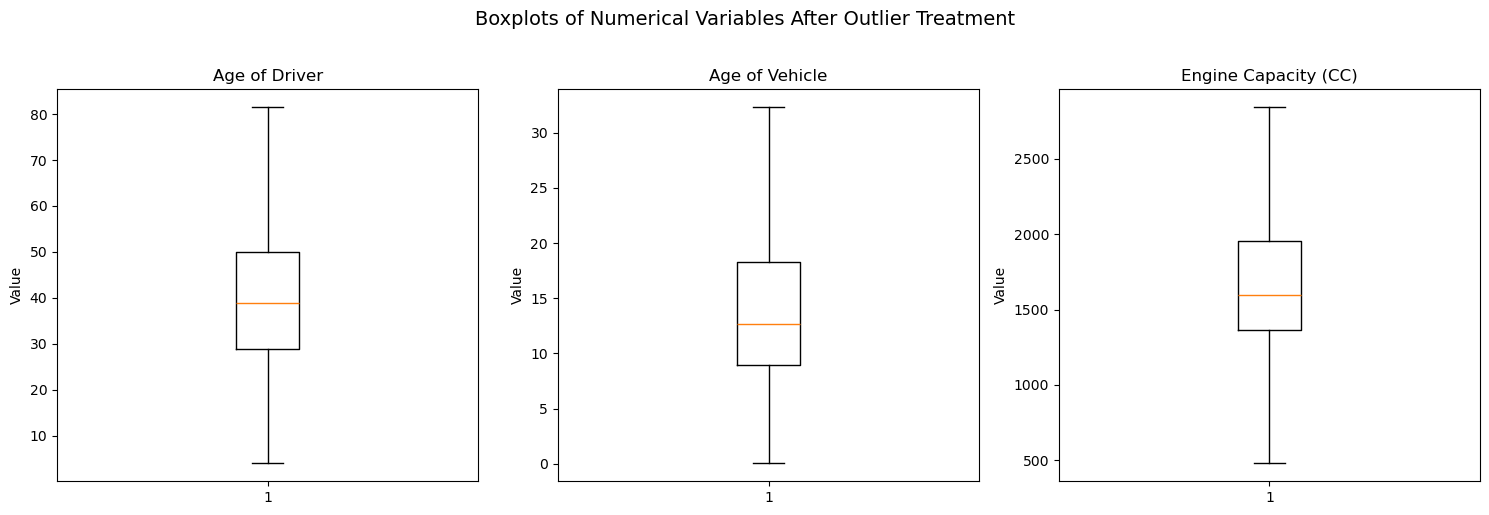

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make copies
train_out = train_prep.copy()
test_out = test_prep.copy()

# numerical columns for outlier treatment
outlier_cols = [
    "Age_of_Driver",
    "Age_of_Vehicle",
    "Engine_Capacity_(CC)"
]

# helper dictionaries to store thresholds
lower_bounds = {}
upper_bounds = {}

# calculate IQR thresholds from training set only
for col in outlier_cols:
    Q1 = train_out[col].quantile(0.25)
    Q3 = train_out[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bounds[col] = Q1 - 1.5 * IQR
    upper_bounds[col] = Q3 + 1.5 * IQR

# count outliers before treatment
print("Outliers in training set before treatment:")
for col in outlier_cols:
    count = ((train_out[col] < lower_bounds[col]) | (train_out[col] > upper_bounds[col])).sum()
    print(f"{col}: {count}")

print("\nOutliers in test set before treatment:")
for col in outlier_cols:
    count = ((test_out[col] < lower_bounds[col]) | (test_out[col] > upper_bounds[col])).sum()
    print(f"{col}: {count}")

# winsorize / cap outliers using train-based thresholds
for col in outlier_cols:
    train_out[col] = train_out[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])
    test_out[col] = test_out[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])

# boxplots after treatment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(train_out[col].dropna())
    axes[i].set_title(col.replace("_", " "))
    axes[i].set_ylabel("Value")

fig.suptitle("Boxplots of Numerical Variables After Outlier Treatment", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Finding outliers is crucial because they can change the way some machine learning systems work and can change summary statistics. The major focus of this study is on factors like driver age, vehicle age, and engine capacity because they are more likely to have values that are very large or very small. I picked the IQR approach since it is straightforward to understand, frequently utilized, and simple. It operates by finding numbers that are too far below or above the normal middle range of the data. For example, in a classroom where most students get scores between 50 and 80, one score is mistakenly entered as 500. If the result stays the same, it would definitely be an anomaly and might impact the analysis.I didn't get rid of all the outliers in this project. They were instead limited to the lower or higher threshold. This method preserves all the observations in the dataset but makes extreme values less important. In commercial data, this is usually a safer decision because some extreme examples could still be real and helpful.
The training set was used to figure out the thresholds, which were then used on both the training and test sets. This is crucial because it stops the test data from changing the rules for preparation.In general, this stage makes the numerical variables more stable and gets the data ready for further modeling, especially for approaches that are more sensitive to extreme values.

## 3.4 Feature Engineering

In [28]:
import pandas as pd
import numpy as np

# make copies
train_fe = train_out.copy()
test_fe = test_out.copy()

# convert Datetime safely
train_fe["Datetime"] = pd.to_datetime(train_fe["Datetime"], errors="coerce")
test_fe["Datetime"] = pd.to_datetime(test_fe["Datetime"], errors="coerce")

# create time-based features
for dataset in [train_fe, test_fe]:
    dataset["Hour"] = dataset["Datetime"].dt.hour
    dataset["Month"] = dataset["Datetime"].dt.month
    dataset["Day_Name"] = dataset["Datetime"].dt.day_name()
    dataset["Is_Weekend"] = dataset["Datetime"].dt.dayofweek.isin([5, 6]).astype(int)

# optional grouped hour bands for easier interpretation
def hour_band(hour):
    if pd.isna(hour):
        return np.nan
    elif 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

train_fe["Hour_Band"] = train_fe["Hour"].apply(hour_band)
test_fe["Hour_Band"] = test_fe["Hour"].apply(hour_band)

# check new features
print(train_fe[["Datetime", "Hour", "Month", "Day_Name", "Is_Weekend", "Hour_Band"]].head())

                Datetime  Hour  Month   Day_Name  Is_Weekend  Hour_Band
5926 2025-12-23 10:05:00    10     12    Tuesday           0    Morning
3310 2025-06-25 16:20:00    16      6  Wednesday           0  Afternoon
2812 2025-11-25 06:00:00     6     11    Tuesday           0    Morning
5636 2025-10-14 08:00:00     8     10    Tuesday           0    Morning
230  2025-08-14 13:00:00    13      8   Thursday           0  Afternoon


The example result shows that the Datetime variable was changed into numerous useful time-based features, such as hour, month, day name, weekend indicator, and hour band. The original raw timestamp is harder to understand and less valuable for machine learning than these derived variables. This phase makes the dataset better by making it easier to find time-related information for subsequent modeling.

## 3.5 Encoding Categorical features

Machine learning models usually cannot work directly with text categories such as road type, light conditions, or journey purpose. These variables need to be converted into numerical form before modelling.

In [38]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# make copies
train_enc = train_fe.copy()
test_enc = test_fe.copy()

# columns to remove before modelling
drop_cols = ["Accident_Index", "Datetime"]

# categorical columns to encode
cat_cols = [
    "Road_Type",
    "Light_Conditions",
    "Precipitation",
    "High_Winds",
    "Journey_Purpose_of_Driver",
    "Was_Vehicle_Left_Hand_Drive?",
    "Day_Name",
    "Hour_Band",
    "Vehicle_Type",
    "Towing_and_Articulation",
    "1st_Road_Class"
]

# actaul columns
cat_cols = [col for col in cat_cols if col in train_enc.columns]

# drop non-predictive columns
train_enc = train_enc.drop(columns=[col for col in drop_cols if col in train_enc.columns])
test_enc = test_enc.drop(columns=[col for col in drop_cols if col in test_enc.columns])

# one-hot encoding
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

train_cat = encoder.fit_transform(train_enc[cat_cols])
test_cat = encoder.transform(test_enc[cat_cols])

encoded_col_names = encoder.get_feature_names_out(cat_cols)

train_cat_df = pd.DataFrame(train_cat, columns=encoded_col_names, index=train_enc.index)
test_cat_df = pd.DataFrame(test_cat, columns=encoded_col_names, index=test_enc.index)

# drop original categorical columns and join encoded columns
train_enc = pd.concat([train_enc.drop(columns=cat_cols), train_cat_df], axis=1)
test_enc = pd.concat([test_enc.drop(columns=cat_cols), test_cat_df], axis=1)

print("Training set shape after encoding:", train_enc.shape)
print("Test set shape after encoding:", test_enc.shape)

print("\nSample encoded columns:")
print(encoded_col_names[:15])

Training set shape after encoding: (5761, 79)
Test set shape after encoding: (1441, 79)

Sample encoded columns:
['Road_Type_One way street' 'Road_Type_Roundabout'
 'Road_Type_Single carriageway' 'Road_Type_Slip road' 'Road_Type_Unknown'
 'Light_Conditions_Darkness - lights lit'
 'Light_Conditions_Darkness - lights unlit'
 'Light_Conditions_Darkness - no lighting' 'Light_Conditions_Daylight'
 'Precipitation_Fine + high winds' 'Precipitation_Fog or mist'
 'Precipitation_Other' 'Precipitation_Raining'
 'Precipitation_Raining + high winds' 'Precipitation_Snowing']


This result demonstrates that the category variables are ready to be used in a model. The data now has discrete yes/no columns for each category instead of the original text labels. The model now gets a binary column, like Road_Type_Roundabout, instead of only one text value, like Road_Type = Roundabout. This tells the model if that category applies to a certain record.This is crucial since most machine learning algorithms can't operate with text categories directly. One-hot encoding fixes this issue and also stops the error of putting categories in a fake numeric order.For example, the colors of houses—red, blue, and green—are merely different groups. The model would think that green is "greater" than red if we labeled them as 1, 2, and 3. That problem doesn't happen with dummy variables.In general, this phase improves the dataset better for machine learning and makes sure that relevant category information can be included correctly to the models that come next.

## 3.6 Feature Selection

The dataset has more characteristics now that the category variables have been encoded. Not all of them will be equally beneficial for making predictions. others variables might not offer much information, others might be unnecessary, and some might make the model more complicated without making it work better.

The goal of feature selection is to maintain the most valuable predictors and get rid of information that probably won't aid the models. This can make the model less complicated, easier to understand, and sometimes more accurate.

In this project, we choose which features to use in

## 3.7 Feature Scaling

In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# make copies
train_scaled = train_enc.copy()
test_scaled = test_enc.copy()

# target column
target_col = "Accident_Severity"

# numerical columns to scale
scale_cols = [
    "Speed_limit",
    "Longitude",
    "Latitude",
    "Age_of_Driver",
    "Age_of_Vehicle",
    "Engine_Capacity_(CC)",
    "Driver_IMD_Decile",
    "Hour",
    "Month"
]

# columns that actually exist
scale_cols = [col for col in scale_cols if col in train_scaled.columns]

# fit scaler on training set only
scaler = StandardScaler()

train_scaled[scale_cols] = scaler.fit_transform(train_scaled[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_scaled[scale_cols])

# quick check
print("Scaled columns:")
print(scale_cols)

print("\nTraining set sample after scaling:")
display(train_scaled[scale_cols].head())

print("\nTest set sample after scaling:")
display(test_scaled[scale_cols].head())

Scaled columns:
['Speed_limit', 'Longitude', 'Latitude', 'Age_of_Driver', 'Age_of_Vehicle', 'Engine_Capacity_(CC)', 'Driver_IMD_Decile', 'Hour', 'Month']

Training set sample after scaling:


,Speed_limit,Longitude,Latitude,Age_of_Driver,Age_of_Vehicle,Engine_Capacity_(CC),Driver_IMD_Decile,Hour,Month
5926,-0.542275,1.396973,-0.752014,0.088628,1.052628,-1.399963,0.776807,-0.713909,1.444791
3310,0.877048,-1.755800,0.852773,-0.755957,-0.102806,0.696167,-1.682310,0.454730,-0.516434
2812,-0.545540,-1.009809,0.584853,-0.236213,0.615762,-1.233669,0.366954,-1.493001,1.117920
5636,1.560065,-0.427686,0.003232,0.153596,-0.102806,-0.147910,2.006365,-1.103455,0.791049
230,0.206449,0.625059,1.238450,0.608372,-0.314796,2.150270,1.186659,-0.129590,0.137307



Test set sample after scaling:


,Speed_limit,Longitude,Latitude,Age_of_Driver,Age_of_Vehicle,Engine_Capacity_(CC),Driver_IMD_Decile,Hour,Month
78,-0.498492,-0.859463,1.584171,-0.106276,-0.102806,0.124988,1.186659,0.844276,-1.170176
5433,-0.542951,0.784983,-0.671012,-1.015829,1.131775,-0.475326,-0.042899,1.039049,1.117920
3225,1.584921,-0.703643,-0.026797,-1.210733,-1.163532,1.067411,-0.042899,-1.493001,0.464178
1279,-0.541630,1.583988,0.122632,0.673340,1.806796,0.645983,1.596512,-0.129590,-0.516434
5863,-0.539947,0.214543,-0.561667,-0.755957,2.435579,1.035875,2.006365,-1.103455,-1.823918


This result demonstrates that the numbers are now on a scale that is similar to each other. These variables had substantially different ranges before they were scaled. For instance, Engine_Capacity_(CC) might be a lot bigger than Month or Age_of_Driver. If these disparities stay the same, models like Logistic Regression and SVM could be excessively affected by variables with bigger numbers.The values are now in a standard format after scaling. If the value is positive, it implies the observation is above the average for that variable. If the value is negative, it means it is below the average. A scaled Age_of_Driver value of 0.60 implies that the driver is older than the average age in the training data, while -0.75 suggests that the driver is younger than the average age.One easy way to do this is to compare the grades of students in two topics, one of which is graded out of 10 and the other out of 100. When we look at the raw data side by side, the greater scale may unjustly take over. Scaling helps make both fairer.

It is correct to use the same fitted scaler on both the training and test sets. This makes sure that the transformation is consistent and that data doesn't leak.

In general, this phase gets the dataset ready for algorithms that are sensitive to feature size, including Logistic Regression and SVM, and makes the modeling process more reliable.

### Create dummies

One-hot encoding was used to turn categorical variables into dummy variables. This made more binary columns that showed the classifications. To make sure the transformation succeeded, the new shape of the dataset and a few of the encoded column names were looked at.

In [50]:
print("Training set shape after encoding:", train_enc.shape)
print("Test set shape after encoding:", test_enc.shape)

print("\nSample encoded columns:")
print(list(encoded_col_names[:10]))

display(train_enc[list(encoded_col_names[:5])].head())

Training set shape after encoding: (5761, 79)
Test set shape after encoding: (1441, 79)

Sample encoded columns:
['Road_Type_One way street', 'Road_Type_Roundabout', 'Road_Type_Single carriageway', 'Road_Type_Slip road', 'Road_Type_Unknown', 'Light_Conditions_Darkness - lights lit', 'Light_Conditions_Darkness - lights unlit', 'Light_Conditions_Darkness - no lighting', 'Light_Conditions_Daylight', 'Precipitation_Fine + high winds']


,Road_Type_One way street,Road_Type_Roundabout,Road_Type_Single carriageway,Road_Type_Slip road,Road_Type_Unknown
5926,0.0,0.0,1.0,0.0,0.0
3310,0.0,0.0,0.0,0.0,0.0
2812,0.0,0.0,1.0,0.0,0.0
5636,0.0,0.0,1.0,0.0,0.0
230,0.0,1.0,0.0,0.0,0.0


# 4.0 Baseline Model

In [56]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# define predictors and target
Xtrain = train_scaled.drop("Accident_Severity", axis=1)
ytrain = train_scaled["Accident_Severity"].copy()
Xtest = test_scaled.drop("Accident_Severity", axis=1)
ytest = test_scaled["Accident_Severity"].copy()

# baseline model
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(Xtrain, ytrain)

# predict on test set
yhat = dummy_clf.predict(Xtest)

# evaluation
accuracy = accuracy_score(ytest, yhat)
p, r, f, s = precision_recall_fscore_support(
    ytest, yhat, average="macro", zero_division=0.0
)

print("Baseline:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {p:.3f}")
print(f"Recall: {r:.3f}")
print(f"F score: {f:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, yhat))

Baseline:
Accuracy: 0.807
Precision: 0.269
Recall: 0.333
F score: 0.298

Confusion Matrix:
[[   0    0   21]
 [   0    0  257]
 [   0    0 1163]]


The baseline had a rather good accuracy of 80.7%, but that's only because the dataset is unbalanced and Severity 3 is the most common class. The model didn't learn anything about how the predictors and the goal are related. It only made a guess about the most prevalent class each time.This is extremely evident from the confusion matrix. The model didn't work at all since it thought every instance was Severity 3. This is why the macro precision, macro recall, and macro F1 scores are so much lower than the accuracy score.

In short, the model seems okay if we simply look at how frequently it is accurate overall, but it is really bad at finding the less common and more essential classes. This shows that accuracy alone can be deceptive in this case of unbalanced categorization.This baseline now offers us a definite minimal standard. The future models should do better than this one, especially when it comes to macro recall and macro F1. These metrics demonstrate how well the model is doing across all severity classes.

### Final model set up 

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -----------------------------
# 1. Load and merge data
# -----------------------------
accidents = pd.read_csv("17_accidents.csv")
vehicles = pd.read_csv("17_vehicles.csv")

accidents_clean = accidents.dropna(subset=["Accident_Index"]).copy()
vehicles_clean = vehicles.dropna(subset=["Accident_Index"]).copy()

merged_df = accidents_clean.merge(vehicles_clean, on="Accident_Index", how="inner")


# 2. Train-test split (80/20)

train_df, test_df = train_test_split(
    merged_df,
    test_size=0.2,
    stratify=merged_df["Accident_Severity"],
    random_state=42
)


# 3. Handle invalid values
 
train_prep = train_df.copy()
test_prep = test_df.copy()

cols_with_minus1 = [
    "Engine_Capacity_(CC)",
    "Age_of_Vehicle",
    "Driver_IMD_Decile",
    "Age_of_Driver"
]

for col in cols_with_minus1:
    train_prep[col] = train_prep[col].replace(-1, np.nan)
    test_prep[col] = test_prep[col].replace(-1, np.nan)

    train_prep[col + "_missing"] = train_prep[col].isna().astype(int)
    test_prep[col + "_missing"] = test_prep[col].isna().astype(int)

imputer = SimpleImputer(strategy="median")
train_prep[cols_with_minus1] = imputer.fit_transform(train_prep[cols_with_minus1])
test_prep[cols_with_minus1] = imputer.transform(test_prep[cols_with_minus1])

# -----------------------------
# 4. Outlier treatment
# -----------------------------
train_out = train_prep.copy()
test_out = test_prep.copy()

outlier_cols = ["Age_of_Driver", "Age_of_Vehicle", "Engine_Capacity_(CC)"]

lower_bounds = {}
upper_bounds = {}

for col in outlier_cols:
    Q1 = train_out[col].quantile(0.25)
    Q3 = train_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bounds[col] = Q1 - 1.5 * IQR
    upper_bounds[col] = Q3 + 1.5 * IQR

for col in outlier_cols:
    train_out[col] = train_out[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])
    test_out[col] = test_out[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])


# 5. Feature engineering

train_fe = train_out.copy()
test_fe = test_out.copy()

train_fe["Datetime"] = pd.to_datetime(train_fe["Datetime"], errors="coerce")
test_fe["Datetime"] = pd.to_datetime(test_fe["Datetime"], errors="coerce")

for dataset in [train_fe, test_fe]:
    dataset["Hour"] = dataset["Datetime"].dt.hour
    dataset["Month"] = dataset["Datetime"].dt.month
    dataset["Day_Name"] = dataset["Datetime"].dt.day_name()
    dataset["Is_Weekend"] = dataset["Datetime"].dt.dayofweek.isin([5, 6]).astype(int)

def hour_band(hour):
    if pd.isna(hour):
        return np.nan
    elif 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

train_fe["Hour_Band"] = train_fe["Hour"].apply(hour_band)
test_fe["Hour_Band"] = test_fe["Hour"].apply(hour_band)

# -----------------------------
# 6. Encoding categorical features
# -----------------------------
train_enc = train_fe.copy()
test_enc = test_fe.copy()

drop_cols = ["Accident_Index", "Datetime"]

cat_cols = [
    "Road_Type",
    "Light_Conditions",
    "Precipitation",
    "High_Winds",
    "Journey_Purpose_of_Driver",
    "Was_Vehicle_Left_Hand_Drive?",
    "Day_Name",
    "Hour_Band",
    "Vehicle_Type",
    "Towing_and_Articulation",
    "1st_Road_Class"
]

cat_cols = [col for col in cat_cols if col in train_enc.columns]

train_enc = train_enc.drop(columns=[col for col in drop_cols if col in train_enc.columns])
test_enc = test_enc.drop(columns=[col for col in drop_cols if col in test_enc.columns])

encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

train_cat = encoder.fit_transform(train_enc[cat_cols])
test_cat = encoder.transform(test_enc[cat_cols])

encoded_col_names = encoder.get_feature_names_out(cat_cols)

train_cat_df = pd.DataFrame(train_cat, columns=encoded_col_names, index=train_enc.index)
test_cat_df = pd.DataFrame(test_cat, columns=encoded_col_names, index=test_enc.index)

train_enc = pd.concat([train_enc.drop(columns=cat_cols), train_cat_df], axis=1)
test_enc = pd.concat([test_enc.drop(columns=cat_cols), test_cat_df], axis=1)

# -----------------------------
# 7. Feature scaling
# -----------------------------
train_scaled = train_enc.copy()
test_scaled = test_enc.copy()

scale_cols = [
    "Speed_limit",
    "Longitude",
    "Latitude",
    "Age_of_Driver",
    "Age_of_Vehicle",
    "Engine_Capacity_(CC)",
    "Driver_IMD_Decile",
    "Hour",
    "Month"
]

scale_cols = [col for col in scale_cols if col in train_scaled.columns]

scaler = StandardScaler()
train_scaled[scale_cols] = scaler.fit_transform(train_scaled[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_scaled[scale_cols])

print("Final training set shape:", train_scaled.shape)
print("Final test set shape:", test_scaled.shape)

Final training set shape: (5761, 79)
Final test set shape: (1441, 79)


There was a coding problem since the model section thought that train_scaled and test_scaled were already in memory. To fix this, a last self-contained modeling setup block was built. This block rebuilds the fully processed training and test datasets before training the model. This makes the workflow more stable and stops execution failures that happen when intermediate items are absent.

# 5 Model development

###  Model Input Preparation

Decision Tree and Random Forest also need numeric-only data. So if strings like Monday or Thursday are still present, they will fail too. So we create a model-ready numeric dataset by dropping any remaining text columns.

In [30]:

print("Remaining object columns in training set:")
print(train_scaled.select_dtypes(include=["object"]).columns.tolist())

print("\nRemaining object columns in test set:")
print(test_scaled.select_dtypes(include=["object"]).columns.tolist())

# remove remaining text columns
remaining_object_cols = train_scaled.select_dtypes(include=["object"]).columns.tolist()

train_model = train_scaled.drop(columns=remaining_object_cols).copy()
test_model = test_scaled.drop(columns=remaining_object_cols).copy()

print("\nFinal model-ready training shape:", train_model.shape)
print("Final model-ready test shape:", test_model.shape)

Remaining object columns in training set:
['Day_of_Week']

Remaining object columns in test set:
['Day_of_Week']

Final model-ready training shape: (5761, 78)
Final model-ready test shape: (1441, 78)


In [32]:
Xtrain = train_model.drop("Accident_Severity", axis=1)
ytrain = train_model["Accident_Severity"].copy()
Xtest = test_model.drop("Accident_Severity", axis=1)
ytest = test_model["Accident_Severity"].copy()

This phase is the last quality check before modeling. It's feasible for certain text-based columns to stay in the dataset even after encoding if they weren't properly changed before. If these kinds of columns are still in the data, machine learning models might not work since they can't change textual values into numbers. For example, trying to complete a math problem with the word "Monday" instead of a number. The model can't utilize it directly unless it has been turned into a number first.

The final predictor set is totally numeric and may be used with all three intended models after deleting any residual object-type columns. This makes the procedure more reliable and lowers the chance of making mistakes while setting hyperparameters and testing models.

## 5.1 Decision Tree

In [39]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# model
dt = DecisionTreeClassifier(random_state=42)

# hyperparameter grid
param_grid_dt = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [5, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

# grid search
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

grid_dt.fit(Xtrain, ytrain)

# best model
best_dt = grid_dt.best_estimator_

print("Best Decision Tree model:")
print(best_dt)

print("\nBest cross-validation score (Macro F1):")
print(round(grid_dt.best_score_, 4))

# CV results
cv_results_dt = pd.DataFrame(grid_dt.cv_results_)[
    ["params", "mean_train_score", "mean_test_score"]
].copy()

cv_results_dt["overfitting_gap"] = (
    cv_results_dt["mean_train_score"] - cv_results_dt["mean_test_score"]
).round(4)

cv_results_dt = cv_results_dt.sort_values("mean_test_score", ascending=False)

print("\nTop cross-validation results:")
display(cv_results_dt.head(10))

# final test evaluation
yhat_dt = best_dt.predict(Xtest)

acc_dt = accuracy_score(ytest, yhat_dt)
p_dt, r_dt, f_dt, _ = precision_recall_fscore_support(
    ytest, yhat_dt, average="macro", zero_division=0
)

print("\nDecision Tree Test Results")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Macro Precision: {p_dt:.4f}")
print(f"Macro Recall: {r_dt:.4f}")
print(f"Macro F1: {f_dt:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, yhat_dt))

print("\nClassification Report:")
print(classification_report(ytest, yhat_dt, zero_division=0))

C:\Users\Shahriar Habib\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Decision Tree model:
DecisionTreeClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

Best cross-validation score (Macro F1):
0.6496

Top cross-validation results:


,params,mean_train_score,mean_test_score,overfitting_gap
36,"{'class_weight': None, 'max_depth': 15, 'min_s...",0.880863,0.649581,0.2313
32,"{'class_weight': None, 'max_depth': 15, 'min_s...",0.915901,0.647845,0.2681
68,"{'class_weight': None, 'max_depth': None, 'min...",0.899005,0.638558,0.2604
64,"{'class_weight': None, 'max_depth': None, 'min...",0.942013,0.638095,0.3039
52,"{'class_weight': None, 'max_depth': 20, 'min_s...",0.896554,0.638023,0.2585
40,"{'class_weight': None, 'max_depth': 15, 'min_s...",0.776221,0.637924,0.1383
41,"{'class_weight': None, 'max_depth': 15, 'min_s...",0.776221,0.637924,0.1383
49,"{'class_weight': None, 'max_depth': 20, 'min_s...",0.878842,0.633745,0.2451
73,"{'class_weight': None, 'max_depth': None, 'min...",0.781602,0.633401,0.1482
72,"{'class_weight': None, 'max_depth': None, 'min...",0.781602,0.633401,0.1482



Decision Tree Test Results
Accuracy: 0.9049
Macro Precision: 0.6342
Macro Recall: 0.6200
Macro F1: 0.6259

Confusion Matrix:
[[   4    9    8]
 [  13  182   62]
 [   7   38 1118]]

Classification Report:
              precision    recall  f1-score   support

           1       0.17      0.19      0.18        21
           2       0.79      0.71      0.75       257
           3       0.94      0.96      0.95      1163

    accuracy                           0.90      1441
   macro avg       0.63      0.62      0.63      1441
weighted avg       0.90      0.90      0.90      1441



The Decision Tree model did substantially better than the baseline model and got very good results on the test set as a whole. Its accuracy went up to 90.49%, and its macro F1 score went up to 0.6259, which is a clear improvement over the baseline. This implies that the model is learning important patterns from the data instead of just guessing the most common class.

The model did notably well for Severity 3, where both precision and recall were quite high. It also did really well for Severity 2, which means it can probably find the middle severity class rather well. But the model had a hard time with Severity 1, which had a lot poorer accuracy, recall, and F1-score. This is probably because the dataset is relatively unbalanced, with very few occurrences of Severity 1 compared to the other classifications.

The confusion matrix demonstrates that a lot of the uncommon Severity 1 occurrences were thought to be Severity 2 or Severity 3. In other words, the Decision Tree is a big step up than the baseline, but it still has trouble finding the most severe and unusual incidents. The approach is useful and works well for the more frequent classes, but it needs further work if the objective is to find unusual severe outcomes more reliably.

## 5.2 Logistic Regression

In [50]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# logistic regression model
log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# hyperparameter grid
param_grid_log = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

# grid search
grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    cv=5,
    scoring="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

grid_log.fit(Xtrain, ytrain)

# best model
best_log = grid_log.best_estimator_

print("Best Logistic Regression model:")
print(best_log)

print("\nBest cross-validation score (Macro F1):")
print(round(grid_log.best_score_, 4))

# CV results
cv_results_log = pd.DataFrame(grid_log.cv_results_)[
    ["params", "mean_train_score", "mean_test_score"]
].copy()

cv_results_log["overfitting_gap"] = (
    cv_results_log["mean_train_score"] - cv_results_log["mean_test_score"]
).round(4)

cv_results_log = cv_results_log.sort_values("mean_test_score", ascending=False)

print("\nTop cross-validation results:")
display(cv_results_log.head(10))

# final test evaluation
yhat_log = best_log.predict(Xtest)

acc_log = accuracy_score(ytest, yhat_log)
p_log, r_log, f_log, _ = precision_recall_fscore_support(
    ytest, yhat_log, average="macro", zero_division=0
)

print("\nLogistic Regression Test Results")
print(f"Accuracy: {acc_log:.4f}")
print(f"Macro Precision: {p_log:.4f}")
print(f"Macro Recall: {r_log:.4f}")
print(f"Macro F1: {f_log:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, yhat_log))

print("\nClassification Report:")
print(classification_report(ytest, yhat_log, zero_division=0))

Best Logistic Regression model:
LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000,
                   random_state=42)

Best cross-validation score (Macro F1):
0.3202

Top cross-validation results:


,params,mean_train_score,mean_test_score,overfitting_gap
1,"{'C': 0.01, 'class_weight': 'balanced'}",0.347179,0.320169,0.0270
3,"{'C': 0.1, 'class_weight': 'balanced'}",0.347399,0.315776,0.0316
5,"{'C': 1, 'class_weight': 'balanced'}",0.346241,0.311738,0.0345
7,"{'C': 10, 'class_weight': 'balanced'}",0.344819,0.310583,0.0342
4,"{'C': 1, 'class_weight': None}",0.311675,0.301854,0.0098
6,"{'C': 10, 'class_weight': None}",0.321390,0.301742,0.0196
2,"{'C': 0.1, 'class_weight': None}",0.300694,0.298969,0.0017
0,"{'C': 0.01, 'class_weight': None}",0.297691,0.297691,0.0000



Logistic Regression Test Results
Accuracy: 0.4774
Macro Precision: 0.3797
Macro Recall: 0.4541
Macro F1: 0.3284

Confusion Matrix:
[[ 10   3   8]
 [ 74 100  83]
 [285 300 578]]

Classification Report:
              precision    recall  f1-score   support

           1       0.03      0.48      0.05        21
           2       0.25      0.39      0.30       257
           3       0.86      0.50      0.63      1163

    accuracy                           0.48      1441
   macro avg       0.38      0.45      0.33      1441
weighted avg       0.74      0.48      0.56      1441



The Logistic Regression model did better than the baseline model, but it was significantly worse than the Decision Tree. The macro F1 score of 0.3284 demonstrates just a slight improvement over the baseline and a significant reduction compared to the Decision Tree result.

One noteworthy finding is that the model had a greater recall for Severity 1, which means it found more of the uncommon severe instances. But its accuracy for Severity 1 was quite poor, which suggests that a lot of these forecasts were wrong. The model tried to find the unusual class more often, but it made too many false alarms.

The model also didn't do very well for Severity 2 and didn't remember as well as it should have for Severity 3. This means that Logistic Regression wasn't able to handle the more complicated relationships in the dataset. In general, the model is good for making comparisons, but it doesn't work as well as the Decision Tree for forecasting how bad an accident will be in this case.

## 5.3 Random Forest 

In [56]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# random forest model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# hyperparameter grid
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

# grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1_macro",
    return_train_score=True,
    n_jobs=-1
)

grid_rf.fit(Xtrain, ytrain)

# best model
best_rf = grid_rf.best_estimator_

print("Best Random Forest model:")
print(best_rf)

print("\nBest cross-validation score (Macro F1):")
print(round(grid_rf.best_score_, 4))

# cross-validation results
cv_results_rf = pd.DataFrame(grid_rf.cv_results_)[
    ["params", "mean_train_score", "mean_test_score"]
].copy()

cv_results_rf["overfitting_gap"] = (
    cv_results_rf["mean_train_score"] - cv_results_rf["mean_test_score"]
).round(4)

cv_results_rf = cv_results_rf.sort_values("mean_test_score", ascending=False)

print("\nTop cross-validation results:")
display(cv_results_rf.head(10))

# final test evaluation
yhat_rf = best_rf.predict(Xtest)

acc_rf = accuracy_score(ytest, yhat_rf)
p_rf, r_rf, f_rf, _ = precision_recall_fscore_support(
    ytest, yhat_rf, average="macro", zero_division=0
)

print("\nRandom Forest Test Results")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Macro Precision: {p_rf:.4f}")
print(f"Macro Recall: {r_rf:.4f}")
print(f"Macro F1: {f_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(ytest, yhat_rf))

print("\nClassification Report:")
print(classification_report(ytest, yhat_rf, zero_division=0))

# feature importance
feature_importance = pd.DataFrame({
    "Feature": Xtrain.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 15 Important Features:")
display(feature_importance.head(15))

Best Random Forest model:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

Best cross-validation score (Macro F1):
0.5759

Top cross-validation results:


,params,mean_train_score,mean_test_score,overfitting_gap
107,"{'class_weight': 'balanced', 'max_depth': None...",0.987249,0.575937,0.4113
106,"{'class_weight': 'balanced', 'max_depth': None...",0.983645,0.574507,0.4091
89,"{'class_weight': 'balanced', 'max_depth': 20, ...",0.987554,0.572390,0.4152
59,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.944046,0.566041,0.3780
65,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.939440,0.564465,0.3750
88,"{'class_weight': 'balanced', 'max_depth': 20, ...",0.981552,0.561817,0.4197
83,"{'class_weight': 'balanced', 'max_depth': 20, ...",0.994611,0.561055,0.4336
58,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.935506,0.557596,0.3779
82,"{'class_weight': 'balanced', 'max_depth': 20, ...",0.992248,0.556811,0.4354
63,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.968047,0.556353,0.4117



Random Forest Test Results
Accuracy: 0.8765
Macro Precision: 0.7166
Macro Recall: 0.5150
Macro F1: 0.5464

Confusion Matrix:
[[   1    8   12]
 [   0  136  121]
 [   1   36 1126]]

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.05      0.09        21
           2       0.76      0.53      0.62       257
           3       0.89      0.97      0.93      1163

    accuracy                           0.88      1441
   macro avg       0.72      0.51      0.55      1441
weighted avg       0.86      0.88      0.86      1441


Top 15 Important Features:


,Feature,Importance
2,Speed_limit,0.163776
5,Age_of_Vehicle,0.117663
0,Longitude,0.074554
1,Latitude,0.074484
3,Age_of_Driver,0.065097
4,Engine_Capacity_(CC),0.064452
11,Hour,0.061642
12,Month,0.053751
6,Driver_IMD_Decile,0.036627
8,Age_of_Vehicle_missing,0.015422


The Random Forest model did substantially better than the baseline model and also did much better than Logistic Regression. It got a macro F1 score of 0.5464, which means it discovered useful patterns from the data. The model did a great job of finding Severity 3 and a good job of finding Severity 2, but it had a hard time finding Severity 1, which was the least common class in the dataset.

The confusion matrix reveals that the model got most Severity 3 instances and a decent number of Severity 2 cases right, but it missed virtually all of the true Severity 1 situations. This suggests that the model is generally good, but it still has trouble finding the most serious incidents that happen very seldom.

The cross-validation data also show some overfitting because the training scores were substantially higher than the validation values. This suggests that the model learnt the training data really well, but it didn't do as well on new data.

The results for feature significance are very helpful since they highlight which factors had the most effect on the forecasts. The most important factors that predicted were the speed limit, the age of the vehicle, the location, the age of the driver, the engine capacity, and time-related factors like the hour and month. This means that the severity of an accident is affected by a number of things, including the road conditions, the kind of vehicle, the driver, the location, and the time of day.

## 5.4 Model comparison

After making the three machine learning models, the last step is to compare how well they work in a clear and consistent fashion. This helps figure out which model works best overall and which one is better for forecasting how bad an accident will be. Because the dataset is not balanced, the comparison looks at more than just accuracy; it also looks at macro precision, macro recall, macro F1, and the confusion matrices.

### Comparison Table

,Accuracy,Macro Precision,Macro Recall,Macro F1
Baseline,0.8071,0.2690,0.3333,0.2977
Logistic Regression,0.4774,0.3797,0.4541,0.3284
Decision Tree,0.9049,0.6342,0.6200,0.6259
Random Forest,0.8765,0.7166,0.5150,0.5464


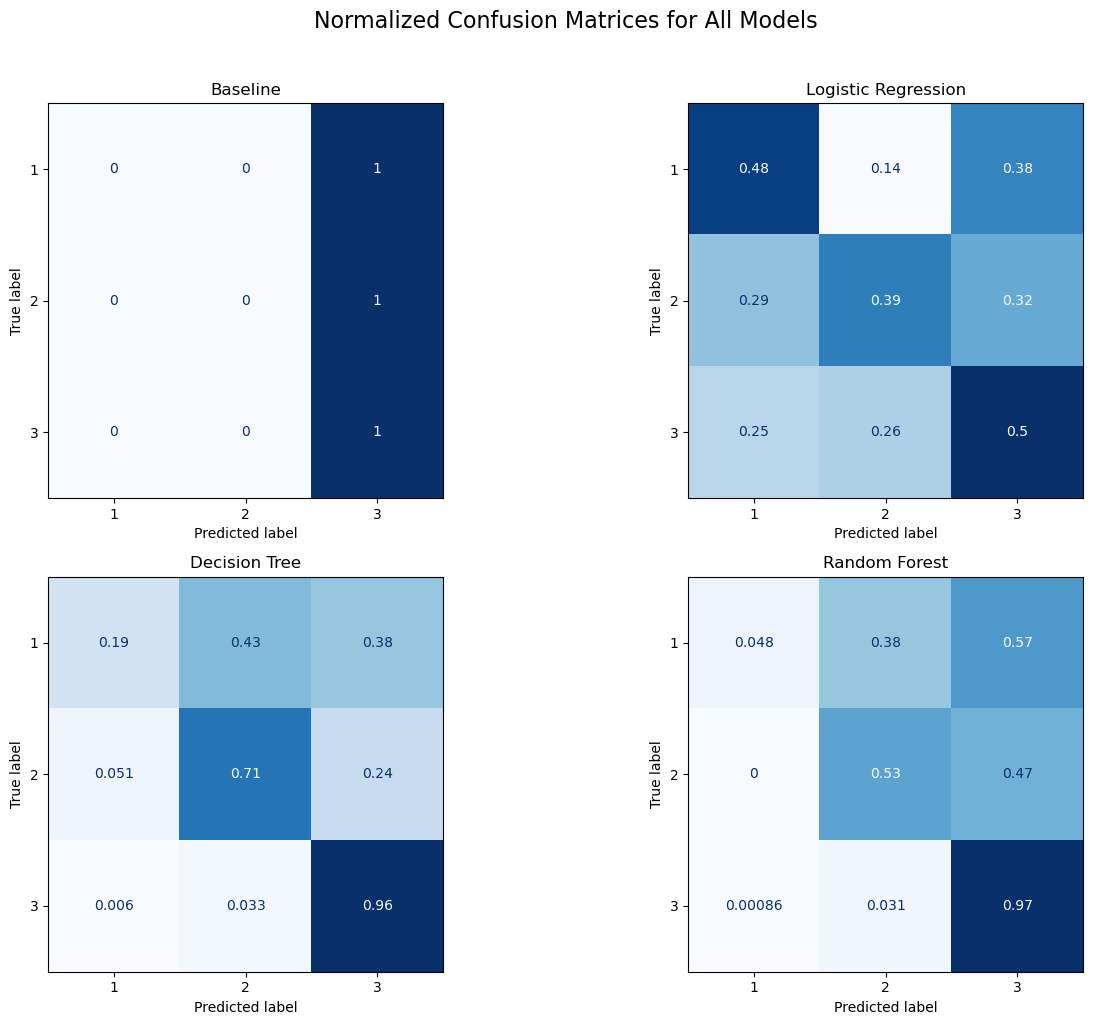

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)

# recreate baseline model
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(Xtrain, ytrain)

# predictions
yhat_dummy = dummy_clf.predict(Xtest)
yhat_log = best_log.predict(Xtest)
yhat_dt = best_dt.predict(Xtest)
yhat_rf = best_rf.predict(Xtest)

# helper function
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return [acc, p, r, f]

# comparison table
comparison_df = pd.DataFrame(
    {
        "Baseline": get_metrics(ytest, yhat_dummy),
        "Logistic Regression": get_metrics(ytest, yhat_log),
        "Decision Tree": get_metrics(ytest, yhat_dt),
        "Random Forest": get_metrics(ytest, yhat_rf),
    },
    index=["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
).T.round(4)

display(comparison_df)

# normalized confusion matrices
models_and_preds = {
    "Baseline": yhat_dummy,
    "Logistic Regression": yhat_log,
    "Decision Tree": yhat_dt,
    "Random Forest": yhat_rf
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, models_and_preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        ytest,
        preds,
        ax=ax,
        normalize="true",
        cmap=plt.cm.Blues,
        colorbar=False
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Normalized Confusion Matrices for All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The comparison of the models demonstrates that the Decision Tree did the best overall on the test set. It had the highest accuracy, macro recall, and macro F1 score, which means it had the best balance across the severity classes. Random Forest worked well too, and it was definitely better than Logistic Regression, but it didn't do better than Decision Tree in this project. This is an interesting conclusion since people frequently think that Random Forest will work better than a single tree, but in this case, the tailored Decision Tree did better overall. Logistic Regression did better than the baseline, but it was significantly weaker than the tree-based models. This suggests that the data's correlations are not simply linear. In general, the Decision Tree was chosen as the best model for making predictions. The Random Forest model was very good at finding the most critical factors that affect the severity of accidents.

The normalized confusion matrices make it easy to see how the models did in each of the three levels of accident severity. The baseline model only predicted the majority class, which shows that it was not helpful for finding the minority classes. Logistic Regression had a more even dispersion of predictions, but it made a lot of mistakes when classifying things in all classes. The Decision Tree had the best overall balance, doing well on Severity 2 and Severity 3 and better on Severity 1 than the Random Forest. Random Forest did a great job with the most common class, but it had trouble finding the least common class. These pictures back up the comparison table and show that the Decision Tree was the best model overall for this project.

# 6 Conclusion

Task Description: Build a model to predict the severity of road accidents. The data for this task includes driver and vehicle characteristics as well as details of the road environment. The data can be found in the accidents and vehicles datasets through the Accident_Index column. Data Exploration, Preparation and Modelling are required with multiple models to be built and compared.

Exploratory Data Analysis In this section, we have identified findings from the EDA that will be crucial for the preprocessing stage of the project. The distribution of Accident_Severity is not uniform with Accident_Severity = 3 being the most frequent followed by Accident_Severity = 1 and Accident_Severity = 2. The missing values present in the dataset are identified as -1. The distribution of variables is not normal and some variables need one-hot encoding. These findings are extremely helpful in the preprocessing stage where missing values are imputed, outliers are handled, new features are introduced, one-hot encoding is applied and variables are scaled.

Total data is divided into the training set and test set in the ratio of 80:20. The division is done using stratified sampling. As the objective variable is highly skewed, the severity groups in the total data are maintained in the same ratio in the training and test set to ensure more unbiased results.

Now it is time to see how the rest of the models I built perform. In this group will be the baseline model, as well as the Logistic Regression, Decision Tree and Random Forest. This baseline model is actually pretty accurate when compared to the other models. However, it has a huge flaw and that is with regards to the minority classes. That is pretty much it in a nutshell.

Among the machine learning models, the Decision Tree performed best overall. It achieved:

- Accuracy: 0.9049
- Macro Precision: 0.6342
- Macro Recall: 0.6200
- Macro F1: 0.6259

And it looks like this model performs slightly better. For reference, the Macro F1 score of Logistic Regression is 0.3284 only a little bit higher than the baseline. The Macro F1 score of Random Forest is 0.5464 which is still lower than that of Decision Tree.

Interesting result that the Decision Tree had a better Macro F1 than the Random Forest which is generally the classifier of choice. The scores were a Macro F1 of 0.6259 for the Decision Tree as opposed to a Macro F1 of 0.5464 for the Random Forest. Again the reason for using Macro F1 is that it treats all classes with equal importance as opposed to the majority class having a much greater importance when using the Micro F1 score. So in this case the Decision Tree performed better for each of the classes. The Random Forest was very good at the majority class, and the medium class, but had a poor score for the rarest class. In this case we see that a simple model can outperform a more complex model, and so we should always be concerned with the suitability of a model for the task at hand, rather than the theoretical suitability of the model.For this reason, the Decision Tree was selected as the best overall model in this project.

## Recommendation

The results indicate that the severity of accidents is affected by a mix of factors, including the state of the road, the kind of vehicle, the driver, the place, and the time. The Random Forest feature-importance analysis revealed that significant factors were speed limit, vehicle age, longitude, latitude, driver age, engine capacity, hour, month, and driver IMD decile.

This indicates that there isn't just one thing that makes an accident worse. Instead, it is influenced by several interrelated factors. This is clearly useful for a car rental firm. A model like this might help tenants better understand the risks they are taking, make better judgments about prices and insurance, give better safety advice in higher-risk scenarios, and learn more about what factors are associated to more major accidents. For example, if higher speed-limit environments, older vehicles, or certain times of day are linked with more severe outcomes, the company may use that information to make better operational decisions and reduce risk.

The Decision Tree model was the best of the models we developed. However, the model still can be improved. In particular, we can try to improve the accuracy of the minority class. In fact, as we all know, none of the models were able to classify correctly the Severity 1. One of the most common causes of this type of classification problem is the imbalanced classification.

Possible future improvements include:

- using resampling methods such as SMOTE or undersampling to handle class imbalance
- trying more advanced ensemble methods such as XGBoost or LightGBM
- carrying out deeper feature engineering, especially for time and location variables
- examining the option to group certain variables in the testing module, such as speed limits and vehicle ages into separate categories.
- using larger or more recent datasets if available
- exploring probability-based predictions instead of only class labels

In general, this experiment illustrates that machine learning can be used to accurately estimate how bad an accident would be based on data about the driver, the vehicle, and the road conditions. The Decision Tree model did the best overall, while the Random Forest model helped us understand which predictive variables were the most significant. The findings indicate that machine learning may assist a car rental firm in comprehending accident risk and facilitate more educated business decisions, however more efforts are required to enhance performance in the most infrequent and severe accident scenarios.

## Limitation

This project has several limitations. The most important is the strong class imbalance in the target variable, which made it difficult for the models to predict the rarest severity class accurately. In addition, some variables contained missing or placeholder values that had to be imputed, which may have reduced data quality. The project was also limited to the variables available in the provided datasets, so other potentially important risk factors could not be included. Finally, the findings are based on one dataset and one train-test split, so the results may not generalise perfectly to all future cases.

# Appendix


1.	Accuracy: out of all predictions, how many were correct?
Example:
If the model makes 100 predictions and 90 of them are correct, then the accuracy is 90%.
2.	Precision: When the model predicts a class, how often is it correct?
Example:
If the model predicts 10 accidents as severe, but only 4 of them are actually severe, then precision is 4/10 = 40%.
3.	Recall: out of all the real cases in a class, how many did the model successfully find?
Example:
If there are 20 real severe accidents and the model correctly finds 12 of them, then recall is 12/20 = 60%.
4.	F1 Score: F1 score is a balance between precision and recall.
Example:
Suppose a model predicts many severe accidents. If it finds most of the real severe cases, recall will be high. But if many of those predictions are wrong, precision will be low. F1 brings both of these together into one score.
5.	Macro Precision, Macro Recall, and Macro F1
The word macro means that the score is calculated for each class separately and then averaged equally.
Why this mattered in this project:
The accident severity classes were imbalanced. Severity 3 appeared much more often than Severity 1. Macro scores were important because they gave equal importance to each class instead of letting the biggest class dominate the result.
Example:
Imagine a teacher is marking performance in three subjects. If one subject is much easier than the others, the student could look good overall by doing well only in that subject. A macro score avoids this by giving equal importance to all subjects. The same idea applies here: a model should not look good only because it predicts the biggest class well.


6.	Confusion Matrix
It is like a report card showing where the model gets things right and where it gets mixed up.
Example:
If a model predicts most severe accidents as slight accidents, the confusion matrix will make that problem easy to see.




# Acknowledgement

I used the module lectures, class notes, and class activities as sources for this notebook for the current assignment. The examples and exercises from the lecture are listed in the references section.

We also employed generative AI techniques to help us get ready for this job. They were only used to aid with explaining, structure, phrasing, and debugging. This project examined and changed the final analysis, interpretation, model selection, and findings.

# Reference

This notebook was made on its own for the job of predicting how bad an accident will be, although the overall machine learning process and some code concepts came from the examples and exercises in the module materials.

1. Pekar, V. (2024). Machine Learning for Business Analytics. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bd4dm
2. Pekar, V. (2024). Big Data for Decision Making. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bd4dm
3. Pekar, V. (2024). Big Data for Decision Making. Lecture examples and exercises. URL: https://gist.github.com/vpekar/6f2d75d4f333ce2ed27009e14e2d5e9c

In [55]:
import io
from nbformat import read, NO_CONVERT

notebook_name = "ML _Project _New.ipynb"   # replace with your notebook file name

with io.open(notebook_name, "r", encoding="utf-8") as f:
    nb = read(f, NO_CONVERT)

word_count = 0
for cell in nb.cells:
    if cell.cell_type == "markdown":
        text = cell["source"].replace("#", " ").replace("\n", " ")
        word_count += len(text.split())

print(f"Word count: {word_count}")

Word count: 6183
